# 🧪 TEAM 2 — LLM & GENERATION PIPELINE (GNN-Entegre)
## LLM-Based Polymer Recipe Generation and Inverse Design Assistant
**Capstone Project | Bahçeşehir University | AI Engineering**

---

### 🎯 Bu Pipeline'ın Projedeki Rolü

LLM bu projede **ara katmandır (intermediate layer)**, nihai karar verici değildir. Akış şudur:

1. **Gerçek polimer verisi** (Team 1) → RAG vektör tabanını besler.
2. **LLM** (Llama 3) → kullanıcının istediği özelliğe göre yeni bir polimer tarifi (SMILES + sentez) üretir.
3. **Gate 1 — RDKit** → üretilen SMILES kimyasal olarak geçerli bir molekül mü? (ön-filtre)
4. **Gate 2 — GNN** → bu molekül gerçekten hedef özelliklere sahip mi / real-life'da üretilebilir mi? (GRAPH doğrulaması)
5. **Feedback** → GNN "uygun değil" derse, hata LLM'e geri beslenir ve LLM sentezi **yeniden üretir**.

> ⚠️ **Kritik fark:** Eski sürümde doğrulama yalnızca RDKit (kimyasal geçerlilik) ile yapılıyordu. Bu sürümde feedback sinyali **GNN'den** gelir — yani "molekül geçerli mi" değil, "molekül istenen özelliklere sahip mi" sorusu sorulur. Bu, projenin bilimsel katma değerinin taşındığı yerdir.

---

### 📋 Sorumluluk Alanı (Tasks 5, 6, 7, 8 + GNN köprüsü)

| Task | Açıklama | Çıktı |
|------|----------|-------|
| **Task 5** | Prompt Engineering | `prompt_library.txt` |
| **Task 6** | Polymer Generation (Llama 3 + RAG) | `llm_raw_output.txt` |
| **Task 7** | Output Parsing & Structuring | `llm_candidates.csv` |
| **Task 8** | SMILES Validation (RDKit = Gate 1) | `valid_candidates.csv` |
| **Gate 2** | GNN doğrulama köprüsü (arayüz hazır) | `team2_task9_ready.csv` |

---

### 🏗️ Mimari (Kapalı Döngü)

```
Gerçek polimer verisi (Team 1)
         │
         ▼
   [RAG: FAISS Vektör DB]
         │
         ▼
   [LLM: Llama 3]  ◄─────────────────────┐
         │                               │
         ▼                               │  FEEDBACK
   [Gate 1: RDKit]  ── geçersiz ─────────┤  (uyuşmazlıkta
         │ geçerli                       │   yeniden üret)
         ▼                               │
   [Gate 2: GNN]  ── özellik uyuşmazlığı ┘
         │ tutarlı
         ▼
   valid_candidates.csv → Task 9 → final_merged_dataset.csv
```

> **⚠️ Colab Notu:** T4 GPU ile çalışacak şekilde optimize edilmiştir.
> Runtime → Change runtime type → T4 GPU seçin.

---

### 🔌 GNN Entegrasyon Durumu

GNN modeli Team 1'in gerçek verisiyle **eğitildikten sonra** devreye girecektir. O zamana kadar:
- `gnn_predict_properties()` fonksiyonu **placeholder** olarak çalışır (`None` döndürür).
- Gate 2 placeholder modunda adayı **otomatik geçirir** (pipeline kırılmaz).
- GNN hazır olunca **tek fonksiyonu** doldurman yeterli — döngü otomatik aktifleşir.

## 📦 BÖLÜM 0 — Kurulum
Gerekli paketleri yükleyin. Bu hücreyi ilk çalıştırmada bir kez çalıştırın.

In [1]:
# KURULUM — Gerekli Kütüphaneler

# 1. RDKit (rdkit-pypi deprecated)
!pip install -q rdkit

# 2. LangChain (requests çakışmasını önlemek için önce yükle)
!pip install -q langchain langchain-community langchain-huggingface

# 3. Vektör DB + Embedding
!pip install -q faiss-cpu sentence-transformers

# 4. Llama 3
!pip install -q "transformers>=4.40.0" accelerate bitsandbytes

# 5. Veri işleme
!pip install -q pandas numpy

# NOT: requests sürümünü DOKUNMADAN bırak.
# langchain-community>=2.32.5, google-colab>=2.32.4 ister;
# pip bu çakışmayı WARNING olarak gösterir ama çalışmayı ENGELLEMEZ.
# Hücreyi çalıştırdıktan sonra Runtime > Restart and run all yapın.

print("✅ Kurulum tamamlandı — Runtime > Restart and run all uygulayın.")


✅ Kurulum tamamlandı — Runtime > Restart and run all uygulayın.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORT — Tüm Kütüphaneler
# ─────────────────────────────────────────────────────────────────────────────
import os
import json
import re
import time
import warnings
import pandas as pd
import numpy as np
from datetime import datetime

# RDKit
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Gereksiz uyarıları sustur

# LangChain
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate

# HuggingFace Transformers (Llama 3)
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    pipeline
)

warnings.filterwarnings('ignore')

# GPU Kontrol
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Kullanılan cihaz: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/tmp/ipykernel_17106/1887794974.py:21: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


🖥️  Kullanılan cihaz: cuda
   GPU: NVIDIA A100-SXM4-80GB
   VRAM: 85.1 GB


## 🔑 BÖLÜM 1 — Kimlik Doğrulama
Llama 3'e erişmek için HuggingFace token gereklidir.
1. https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct adresinde model erişim izni isteyin
2. https://huggingface.co/settings/tokens adresinden token oluşturun

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 1 — HuggingFace Kimlik Doğrulama
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import userdata
from huggingface_hub import login

# Colab Secrets'tan token al (Colab sol menü → 🔑 Secrets → HF_TOKEN ekle)
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    login(token=HF_TOKEN)
    print("✅ HuggingFace girişi başarılı.")
except Exception:
    # Manuel token girişi
    print("⚠️  Colab Secrets bulunamadı. Manuel giriş yapılıyor...")
    HF_TOKEN = input("HuggingFace Token'ınızı girin: ").strip()
    login(token=HF_TOKEN)
    print("✅ HuggingFace girişi başarılı.")

⚠️  Colab Secrets bulunamadı. Manuel giriş yapılıyor...
HuggingFace Token'ınızı girin: [REDACTED]
✅ HuggingFace girişi başarılı.


In [4]:
from huggingface_hub import model_info

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

print(f"🔍 Verifying access to {MODEL_ID}...")
try:
    # This will attempt to fetch model metadata, failing if access is denied.
    info = model_info(MODEL_ID)
    print("✅ Access verified! You have permission to download the model.")
    print("You can now proceed to run the model loading cell.")
except Exception as e:
    print("❌ Access is still denied or an error occurred.")
    print(f"Details: {e}")
    print("\nPlease make sure you accepted the license on the model's Hugging Face page")
    print("and that your token has 'Read' access to the repository.")

🔍 Verifying access to meta-llama/Llama-3.1-8B-Instruct...
✅ Access verified! You have permission to download the model.
You can now proceed to run the model loading cell.


## 📊 BÖLÜM 2 — Referans Veri Havuzu (RAG Bilgi Tabanı)
Team 1'in `clean_dataset.csv` dosyasını beklerken, gerçekçi sentetik polimer verileriyle RAG altyapısını başlatıyoruz. **Task 9'da gerçek veriyle değiştirilecektir.**

In [5]:
# # ─────────────────────────────────────────────────────────────────────────────
# # BÖLÜM 2A — Referans Polimer Veri Tabanı
# # NOT: Team 1'in clean_dataset.csv'si geldiğinde bu satırı değiştirin:
# #   df_reference = pd.read_csv('clean_dataset.csv')
# # ─────────────────────────────────────────────────────────────────────────────

# REFERENCE_POLYMERS = [
#     {
#         "polymer_name": "Polyvinylidene Fluoride (PVDF)",
#         "smiles": "C(F)(F)CC(F)(F)C",  # Tekrar birimi
#         "dielectric_constant": 8.4,
#         "band_gap_eV": 6.2,
#         "Tg_K": 233.0,
#         "monomer": "vinylidene fluoride",
#         "reaction_type": "radical polymerization",
#         "temperature_K": 333.0,
#         "solvent": "DMF",
#         "reaction_time_hours": 8.0,
#         "source": "PolymerGenome"
#     },
#     {
#         "polymer_name": "Polyethylene Terephthalate (PET)",
#         "smiles": "O=C(OCCO)c1ccc(C(=O)O)cc1",
#         "dielectric_constant": 3.3,
#         "band_gap_eV": 4.1,
#         "Tg_K": 347.0,
#         "monomer": "terephthalic acid, ethylene glycol",
#         "reaction_type": "condensation polymerization",
#         "temperature_K": 553.0,
#         "solvent": "no solvent (melt)",
#         "reaction_time_hours": 4.0,
#         "source": "PoLyInfo"
#     },
#     {
#         "polymer_name": "Polystyrene (PS)",
#         "smiles": "c1ccc(CC)cc1",
#         "dielectric_constant": 2.6,
#         "band_gap_eV": 4.4,
#         "Tg_K": 373.0,
#         "monomer": "styrene",
#         "reaction_type": "free radical polymerization",
#         "temperature_K": 343.0,
#         "solvent": "toluene",
#         "reaction_time_hours": 6.0,
#         "source": "PolymerGenome"
#     },
#     {
#         "polymer_name": "Polyimide (PI)",
#         "smiles": "O=C1NC(=O)c2ccccc21",
#         "dielectric_constant": 3.5,
#         "band_gap_eV": 3.8,
#         "Tg_K": 623.0,
#         "monomer": "pyromellitic dianhydride, 4,4'-diaminodiphenyl ether",
#         "reaction_type": "polycondensation",
#         "temperature_K": 473.0,
#         "solvent": "NMP",
#         "reaction_time_hours": 12.0,
#         "source": "PoLyInfo"
#     },
#     {
#         "polymer_name": "Poly(methyl methacrylate) (PMMA)",
#         "smiles": "COC(=O)C(C)C",
#         "dielectric_constant": 3.6,
#         "band_gap_eV": 5.5,
#         "Tg_K": 378.0,
#         "monomer": "methyl methacrylate",
#         "reaction_type": "radical polymerization",
#         "temperature_K": 343.0,
#         "solvent": "acetone",
#         "reaction_time_hours": 5.0,
#         "source": "PolymerGenome"
#     },
#     {
#         "polymer_name": "Polyethylene (PE)",
#         "smiles": "CCCC",
#         "dielectric_constant": 2.3,
#         "band_gap_eV": 8.8,
#         "Tg_K": 150.0,
#         "monomer": "ethylene",
#         "reaction_type": "Ziegler-Natta polymerization",
#         "temperature_K": 353.0,
#         "solvent": "hexane",
#         "reaction_time_hours": 2.0,
#         "source": "PolymerGenome"
#     },
#     {
#         "polymer_name": "Polycarbonate (PC)",
#         "smiles": "CC(C)(c1ccccc1)c1ccccc1",
#         "dielectric_constant": 2.9,
#         "band_gap_eV": 4.5,
#         "Tg_K": 423.0,
#         "monomer": "bisphenol A, phosgene",
#         "reaction_type": "interfacial polycondensation",
#         "temperature_K": 298.0,
#         "solvent": "DCM",
#         "reaction_time_hours": 3.0,
#         "source": "PoLyInfo"
#     },
#     {
#         "polymer_name": "Poly(vinylidene fluoride-co-trifluoroethylene) P(VDF-TrFE)",
#         "smiles": "C(F)(F)CC(F)(F)CF",
#         "dielectric_constant": 18.0,
#         "band_gap_eV": 5.8,
#         "Tg_K": 248.0,
#         "monomer": "vinylidene fluoride, trifluoroethylene",
#         "reaction_type": "emulsion radical copolymerization",
#         "temperature_K": 313.0,
#         "solvent": "water",
#         "reaction_time_hours": 10.0,
#         "source": "PolymerGenome"
#     },
#     {
#         "polymer_name": "Polyaniline (PANI)",
#         "smiles": "Nc1ccccc1",
#         "dielectric_constant": 12.0,
#         "band_gap_eV": 2.8,
#         "Tg_K": 428.0,
#         "monomer": "aniline",
#         "reaction_type": "oxidative polymerization",
#         "temperature_K": 273.0,
#         "solvent": "HCl aqueous",
#         "reaction_time_hours": 2.0,
#         "source": "literature"
#     },
#     {
#         "polymer_name": "Polytetrafluoroethylene (PTFE)",
#         "smiles": "C(F)(F)(F)F",
#         "dielectric_constant": 2.1,
#         "band_gap_eV": 10.0,
#         "Tg_K": 393.0,
#         "monomer": "tetrafluoroethylene",
#         "reaction_type": "radical polymerization",
#         "temperature_K": 298.0,
#         "solvent": "water",
#         "reaction_time_hours": 4.0,
#         "source": "PolymerGenome"
#     }
# ]

# df_reference = pd.DataFrame(REFERENCE_POLYMERS)
# print(f"✅ Referans polimer veritabanı yüklendi: {len(df_reference)} polimer")
# print(f"\n📊 Özellik Aralıkları:")
# print(f"   Dielektrik Sabiti: {df_reference['dielectric_constant'].min():.1f} – {df_reference['dielectric_constant'].max():.1f}")
# print(f"   Band Gap (eV):     {df_reference['band_gap_eV'].min():.1f} – {df_reference['band_gap_eV'].max():.1f}")
# print(f"   Tg (K):            {df_reference['Tg_K'].min():.0f} – {df_reference['Tg_K'].max():.0f}")
# df_reference.head(3)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 2B — Team 1 Verisi Varsa Yükle
# Bu hücreyi Team 1'in dosyaları geldiğinde çalıştırın
# ─────────────────────────────────────────────────────────────────────────────

import os

# Google Drive Bağlantısı (opsiyonel)
from google.colab import drive
drive.mount('/content/drive')
team1_path = "/content/drive/MyDrive/clean_dataset.csv"

if os.path.exists(team1_path):
    df_team1 = pd.read_csv(team1_path)
    # Gerekli sütunları kontrol et
    required_cols = ['smiles', 'dielectric_constant', 'band_gap_eV', 'Tg_predicted_K']
    if all(c in df_team1.columns for c in required_cols):
        df_reference = df_team1.copy()
        print(f"✅ Team 1 verisi yüklendi: {len(df_reference)} polimer")
    else:
        missing = [c for c in required_cols if c not in df_team1.columns]
        print(f"⚠️  Team 1 verisinde eksik sütunlar: {missing}")
        print("   Varsayılan referans veri kullanılıyor...")
else:
    print("ℹ️  clean_dataset.csv bulunamadı → Varsayılan referans veri kullanılıyor")

Mounted at /content/drive
✅ Team 1 verisi yüklendi: 32 polimer


## 📌 BÖLÜM 3 — Task 5: Prompt Kütüphanesi
Üç farklı prompt stratejisi tanımlanıyor.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 3 — TASK 5: Prompt Kütüphanesi (Geçerli SMILES için güçlendirilmiş)
# 3 strateji: Property→Polymer | Polymer→Synthesis | Multi-Candidate
#
# DÜZELTME: Önceki sürümde model köşeli atom ([C], [CH2]) kullanıp geçersiz
# SMILES üretiyordu. Artık her prompt:
#   (1) katı notasyon kuralları,
#   (2) RDKit-doğrulanmış few-shot örnekler,
#   (3) "geçerli bir yapıyı değiştir" yönlendirmesi içeriyor.
# ─────────────────────────────────────────────────────────────────────────────

SMILES_RULES = r"""SMILES NOTATION RULES (follow EXACTLY, these prevent invalid output):
- Use ONLY plain atoms: C, N, O, F, S, Cl, Br for main chain; lowercase c, n, o, s ONLY inside aromatic rings.
- NEVER use bracketed atoms like [C], [CH2], [CH], [N] for normal atoms. Brackets are ONLY for charged atoms ([N+], [O-]).
- Write the polymer REPEAT UNIT with exactly TWO attachment points marked by * at the two ends. Example: *CC* for polyethylene.
- Keep the repeat unit SMALL: 4 to 20 heavy atoms.
- Every ring-opening digit must appear EXACTLY twice (e.g. c1ccccc1). Every parenthesis must be balanced.
- Do NOT exceed valency: C has max 4 bonds, N max 3, O max 2.

VALID polymer SMILES examples (copy this style):
- Polyethylene:      *CC*
- Polypropylene:     *CC(C)*
- PVC:               *CC(Cl)*
- Polystyrene:       *CC(c1ccccc1)*
- PMMA:              *CC(C)(C(=O)OC)*
- PVDF:              *CC(F)(F)*
- Polyacrylonitrile: *CC(C#N)*
- PEO:               *CCO*
- PVAc:              *CC(OC(C)=O)*

STRATEGY: Pick the closest VALID example or a REFERENCE structure below, then MODIFY its
functional groups to hit the target. Modifying a known-valid structure is far safer than
inventing one from scratch."""

PROMPT_PROPERTY_TO_POLYMER = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert polymer chemist specializing in inverse material design for energy applications.
Design a polymer that meets the target properties. Output ONLY a single valid JSON object.

SMILES NOTATION RULES (follow EXACTLY, these prevent invalid output):
- Use ONLY plain atoms: C, N, O, F, S, Cl, Br for main chain; lowercase c, n, o, s ONLY inside aromatic rings.
- NEVER use bracketed atoms like [C], [CH2], [CH], [N] for normal atoms. Brackets are ONLY for charged atoms ([N+], [O-]).
- Write the polymer REPEAT UNIT with exactly TWO attachment points marked by * at the two ends. Example: *CC* for polyethylene.
- Keep the repeat unit SMALL: 4 to 20 heavy atoms.
- Every ring-opening digit must appear EXACTLY twice (e.g. c1ccccc1). Every parenthesis must be balanced.
- Do NOT exceed valency: C has max 4 bonds, N max 3, O max 2.

VALID polymer SMILES examples (copy this style):
- Polyethylene:      *CC*
- Polypropylene:     *CC(C)*
- PVC:               *CC(Cl)*
- Polystyrene:       *CC(c1ccccc1)*
- PMMA:              *CC(C)(C(=O)OC)*
- PVDF:              *CC(F)(F)*
- Polyacrylonitrile: *CC(C#N)*
- PEO:               *CCO*
- PVAc:              *CC(OC(C)=O)*

STRATEGY: Pick the closest VALID example or a REFERENCE structure below, then MODIFY its
functional groups to hit the target. Modifying a known-valid structure is far safer than
inventing one from scratch.
<|eot_id|><|start_header_id|>user<|end_header_id|>

TARGET PROPERTIES:
- Dielectric Constant: {dielectric_constant}
- Band Gap: {band_gap_eV} eV
- Glass Transition Temperature: {Tg_K} K

REFERENCE POLYMERS (from literature database):
{retrieved_context}

Output ONLY this JSON object (no markdown, no extra text):
{{
  "candidate_id": "CAND_{candidate_id}",
  "strategy": "property_to_polymer",
  "target_properties": {{
    "dielectric_constant": {dielectric_constant},
    "band_gap_eV": {band_gap_eV},
    "Tg_K": {Tg_K}
  }},
  "polymer_SMILES": "*CC*",
  "monomers": ["ethylene"],
  "synthesis_conditions": {{
    "reaction_type": "radical polymerization",
    "temperature_K": 350.0,
    "solvent": "toluene",
    "reaction_time_hours": 6.0
  }},
  "design_rationale": "one sentence"
}}

Replace the example values above with your actual design. Keep the SMILES style identical to the examples (plain atoms, * endpoints).
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

PROMPT_POLYMER_TO_SYNTHESIS = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert polymer synthesis chemist. Given a polymer structure, provide a detailed synthesis protocol.
Output ONLY valid JSON. No explanations. Keep polymer_SMILES EXACTLY as given.
<|eot_id|><|start_header_id|>user<|end_header_id|>

POLYMER SMILES (keep exactly): {smiles}
KNOWN PROPERTIES: Dielectric={dielectric_constant}, Band Gap={band_gap_eV} eV, Tg={Tg_K} K

REFERENCE SYNTHESIS PROTOCOLS:
{retrieved_context}

Output ONLY this JSON object:
{{
  "candidate_id": "SYN_{candidate_id}",
  "strategy": "polymer_to_synthesis",
  "polymer_SMILES": "{smiles}",
  "monomers": ["monomer name"],
  "synthesis_conditions": {{
    "reaction_type": "radical polymerization",
    "temperature_K": 350.0,
    "solvent": "toluene",
    "reaction_time_hours": 6.0,
    "catalyst": "AIBN",
    "atmosphere": "N2"
  }},
  "purification": "precipitation in methanol",
  "yield_percent": 75.0
}}

Replace values with realistic ones for the given polymer. Keep polymer_SMILES unchanged.
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

PROMPT_MULTI_CANDIDATE = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are an expert polymer chemist. Generate THREE distinct polymer candidates with DIFFERENT backbones.
Output ONLY valid JSON (an array of 3 objects).

SMILES NOTATION RULES (follow EXACTLY, these prevent invalid output):
- Use ONLY plain atoms: C, N, O, F, S, Cl, Br for main chain; lowercase c, n, o, s ONLY inside aromatic rings.
- NEVER use bracketed atoms like [C], [CH2], [CH], [N] for normal atoms. Brackets are ONLY for charged atoms ([N+], [O-]).
- Write the polymer REPEAT UNIT with exactly TWO attachment points marked by * at the two ends. Example: *CC* for polyethylene.
- Keep the repeat unit SMALL: 4 to 20 heavy atoms.
- Every ring-opening digit must appear EXACTLY twice (e.g. c1ccccc1). Every parenthesis must be balanced.
- Do NOT exceed valency: C has max 4 bonds, N max 3, O max 2.

VALID polymer SMILES examples (copy this style):
- Polyethylene:      *CC*
- Polypropylene:     *CC(C)*
- PVC:               *CC(Cl)*
- Polystyrene:       *CC(c1ccccc1)*
- PMMA:              *CC(C)(C(=O)OC)*
- PVDF:              *CC(F)(F)*
- Polyacrylonitrile: *CC(C#N)*
- PEO:               *CCO*
- PVAc:              *CC(OC(C)=O)*

STRATEGY: Pick the closest VALID example or a REFERENCE structure below, then MODIFY its
functional groups to hit the target. Modifying a known-valid structure is far safer than
inventing one from scratch.
<|eot_id|><|start_header_id|>user<|end_header_id|>

TARGET PROFILE: {design_goal}
TARGET PROPERTIES:
- Dielectric Constant: {dielectric_constant}
- Band Gap: {band_gap_eV} eV
- Tg: {Tg_K} K

REFERENCE EXAMPLES:
{retrieved_context}

Output ONLY this JSON array (3 candidates, each with a DIFFERENT valid SMILES):
[
  {{
    "candidate_id": "MC_{candidate_id}_A",
    "strategy": "multi_candidate",
    "polymer_SMILES": "*CC(c1ccccc1)*",
    "monomers": ["styrene"],
    "synthesis_conditions": {{"reaction_type": "radical polymerization", "temperature_K": 350.0, "solvent": "toluene", "reaction_time_hours": 6.0}},
    "target_properties": {{"dielectric_constant": {dielectric_constant}, "band_gap_eV": {band_gap_eV}, "Tg_K": {Tg_K}}},
    "design_rationale": "one sentence"
  }},
  {{
    "candidate_id": "MC_{candidate_id}_B",
    "strategy": "multi_candidate",
    "polymer_SMILES": "*CC(F)(F)*",
    "monomers": ["vinylidene fluoride"],
    "synthesis_conditions": {{"reaction_type": "emulsion polymerization", "temperature_K": 320.0, "solvent": "water", "reaction_time_hours": 10.0}},
    "target_properties": {{"dielectric_constant": {dielectric_constant}, "band_gap_eV": {band_gap_eV}, "Tg_K": {Tg_K}}},
    "design_rationale": "one sentence"
  }},
  {{
    "candidate_id": "MC_{candidate_id}_C",
    "strategy": "multi_candidate",
    "polymer_SMILES": "*CC(C#N)*",
    "monomers": ["acrylonitrile"],
    "synthesis_conditions": {{"reaction_type": "radical polymerization", "temperature_K": 330.0, "solvent": "DMF", "reaction_time_hours": 8.0}},
    "target_properties": {{"dielectric_constant": {dielectric_constant}, "band_gap_eV": {band_gap_eV}, "Tg_K": {Tg_K}}},
    "design_rationale": "one sentence"
  }}
]

Replace the example SMILES with your own VALID designs (plain atoms, * endpoints, different backbones).
<|eot_id|><|start_header_id|>assistant<|end_header_id|>
"""

# Prompt kütüphanesini kaydet (Task 5 Deliverable)
PROMPT_LIBRARY = {
    "strategy_1_property_to_polymer": PROMPT_PROPERTY_TO_POLYMER,
    "strategy_2_polymer_to_synthesis": PROMPT_POLYMER_TO_SYNTHESIS,
    "strategy_3_multi_candidate": PROMPT_MULTI_CANDIDATE
}

with open("prompt_library.txt", "w", encoding="utf-8") as f:
    for name, prompt in PROMPT_LIBRARY.items():
        f.write("=" * 60 + "\n")
        f.write("PROMPT: " + name + "\n")
        f.write("=" * 60 + "\n")
        f.write(prompt)
        f.write("\n\n")

print("✅ Task 5 tamamlandı → prompt_library.txt kaydedildi")
print("   3 strateji + katı SMILES notasyon kuralları + few-shot örnekler")


✅ Task 5 tamamlandı → prompt_library.txt kaydedildi
   3 strateji + katı SMILES notasyon kuralları + few-shot örnekler


## 🤖 BÖLÜM 4 — Llama 3 Model Yükleme

Llama-3.1-8B-Instruct modelini 4-bit quantization ile yükler (T4 GPU uyumlu).

> **🔧 Bu sürümdeki düzeltmeler:**
> - `max_length=20` çakışması giderildi (modelin varsayılan `generation_config`'i temizlendi) — eski sürümde çıktılar 20 token'da kesiliyordu.
> - Llama 3 sonlandırma token'ı (`<|eot_id|>`) terminator olarak eklendi — model artık tam JSON üretip duruyor.
> - `temperature` 0.3'e düşürüldü — SMILES gibi yapılı çıktılarda tutarlılık artar.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 4 — Llama 3 Model Yükleme (4-bit Quantization)
# T4 GPU: ~15 GB VRAM → 4-bit ile ~5 GB kullanılır
# ─────────────────────────────────────────────────────────────────────────────

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# Zararsız "max_length=20" uyarı spam'ını sustur (max_new_tokens zaten kazanıyor)
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

print(f"📥 Model yükleniyor: {MODEL_ID}")
print("   Bu işlem 3-5 dakika sürebilir...")

# 4-bit quantization konfigürasyonu (T4 GPU bellek optimizasyonu)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
    torch_dtype=torch.bfloat16
)
model.eval()

# ─── KRİTİK DÜZELTME: max_length=20 çakışmasını gider ───
# Modelin generation_config'inde varsayılan max_length=20 var; bu, çıktıyı
# 20 token'da keserek "boş yanıt" gibi görünmesine yol açıyordu.
model.generation_config.max_length = None
model.generation_config.max_new_tokens = 768
model.generation_config.pad_token_id = tokenizer.eos_token_id

# Llama 3 sonlandırma token'ı: <|eot_id|>
EOT_ID = tokenizer.convert_tokens_to_ids("<|eot_id|>")
TERMINATORS = [tokenizer.eos_token_id, EOT_ID]

# HuggingFace pipeline
llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=768,
    do_sample=True,
    temperature=0.3,          # SMILES tutarlılığı için düşük
    top_p=0.85,
    repetition_penalty=1.1,
    return_full_text=False,
    eos_token_id=TERMINATORS,
    pad_token_id=tokenizer.eos_token_id
)

print(f"\n✅ Llama 3.1 hazır!")
print(f"   max_new_tokens=768 | temperature=0.3 | EOT terminator aktif")
if device == "cuda":
    allocated = torch.cuda.memory_allocated() / 1e9
    print(f"   GPU Bellek Kullanımı: {allocated:.1f} GB")

📥 Model yükleniyor: meta-llama/Llama-3.1-8B-Instruct
   Bu işlem 3-5 dakika sürebilir...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]


✅ Llama 3.1 hazır!
   max_new_tokens=768 | temperature=0.3 | EOT terminator aktif
   GPU Bellek Kullanımı: 5.7 GB


## 🔍 BÖLÜM 5 — RAG: Vektör Veritabanı Kurulumu
Referans polimerleri FAISS vektör tabanına yüklüyoruz.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 5 — RAG: FAISS Vektör Veritabanı
# ─────────────────────────────────────────────────────────────────────────────

print("📐 Embedding modeli yükleniyor...")

# Embedding modeli (hafif, kimya metinleri için uygun)
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": device}
)

# Her polimeri zengin metin belgesine dönüştür
def polymer_to_document(row):
    """Polimer kaydını RAG için doğal dil belgesine dönüştür."""
    text = (
        f"Polymer: {row.get('polymer_name', 'Unknown')}. "
        f"SMILES: {row.get('smiles', 'N/A')}. "
        f"Dielectric constant: {row.get('dielectric_constant', 'N/A')}. "
        f"Band gap: {row.get('band_gap_eV', 'N/A')} eV. "
        f"Glass transition temperature: {row.get('Tg_K', 'N/A')} K. "
        f"Monomer(s): {row.get('monomer', 'N/A')}. "
        f"Synthesis: {row.get('reaction_type', 'N/A')} at {row.get('temperature_K', 'N/A')} K "
        f"in {row.get('solvent', 'N/A')} for {row.get('reaction_time_hours', 'N/A')} hours. "
        f"Source: {row.get('source', 'N/A')}."
    )
    metadata = {
        "smiles": str(row.get('smiles', '')),
        "dielectric": float(row.get('dielectric_constant', 0)),
        "band_gap": float(row.get('band_gap_eV', 0)),
        "Tg": float(row.get('Tg_K', 0)),
    }
    return Document(page_content=text, metadata=metadata)

# Dokümanları oluştur ve FAISS'e yükle
documents = [polymer_to_document(row) for _, row in df_reference.iterrows()]
vectorstore = FAISS.from_documents(documents, embedding_model)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"✅ FAISS vektör tabanı hazır: {len(documents)} polimer indekslendi")

# Test: Benzer polimer ara
test_query = "high dielectric constant polymer for capacitor applications"
test_results = retriever.invoke(test_query)
print(f"\n🔎 Test sorgusu: '{test_query}'")
print(f"   En yakın 3 polimer:")
for i, doc in enumerate(test_results, 1):
    print(f"   {i}. {doc.page_content[:100]}...")

📐 Embedding modeli yükleniyor...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ FAISS vektör tabanı hazır: 32 polimer indekslendi

🔎 Test sorgusu: 'high dielectric constant polymer for capacitor applications'
   En yakın 3 polimer:
   1. Polymer: Unknown. SMILES: [*]C(F)(F)C(Cl)(F)[*]. Dielectric constant: 2.6. Band gap: 6.0 eV. Glass t...
   2. Polymer: Unknown. SMILES: [*][Si](C)(C)O[*]. Dielectric constant: 2.7. Band gap: 7.0 eV. Glass trans...
   3. Polymer: Unknown. SMILES: [*]CC(C)(C(=O)OC)[*]. Dielectric constant: 3.3. Band gap: 5.6 eV. Glass tr...


## ⚙️ BÖLÜM 6 — Pipeline Fonksiyonları + İki Kapılı Doğrulama

Bu bölüm pipeline'ın kalbidir. İki doğrulama kapısı (gate) ve bunları kullanan
self-correction döngüsü burada tanımlanır.

| Fonksiyon | Rol |
|-----------|-----|
| `retrieve_similar_polymers` | RAG: hedefe yakın referans polimerleri getirir |
| `call_llama3` | Llama 3'ü çağırır (boş yanıtı güvenli yönetir) |
| `extract_json_from_output` | Task 7: ham metinden JSON ayrıştırır |
| `validate_smiles_rdkit` | **Gate 1:** SMILES kimyasal olarak geçerli mi? |
| `gnn_gate` | **Gate 2:** GNN tahmini hedefle uyuşuyor mu? |
| `generate_with_self_correction` | Üretim + iki kapı + feedback döngüsü |

> **🔧 Bu sürümdeki düzeltmeler:**
> - Boş yanıt artık `None` döndürür ve döngüyü kilitlemez.
> - Self-correction her denemede prompt'u şişirmek yerine **baştan kurar** — eski sürümde prompt büyüdükçe model boş yanıt veriyordu.
> - BigSMILES endpoint işaretleri (`[*]`, `*`) doğrulamadan önce temizlenir.
> - **Feedback sinyali RDKit'ten GNN'e taşındı:** artık "SMILES geçersiz" yerine "GNN özellik tahmini hedefle uyuşmadı" mesajı geri beslenir.
> - `DEBUG_MODE` ile modelin ham çıktısı incelenebilir.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 6 — Pipeline Fonksiyonları + İki Kapılı Doğrulama
# ─────────────────────────────────────────────────────────────────────────────

DEBUG_MODE = True   # True → modelin ham çıktısının ilk 200 karakterini gösterir
GNN_TOLERANCE = 0.25   # GNN tahmini hedeften %15'ten fazla saparsa feedback ver


# ── RAG: Benzer polimerleri getir ───────────────────────────────────────────
def retrieve_similar_polymers(dielectric, band_gap, Tg, k=3):
    query = (f"polymer with dielectric constant {dielectric}, "
             f"band gap {band_gap} eV, "
             f"glass transition temperature {Tg} K")
    docs = retriever.invoke(query)
    parts = []
    for i, doc in enumerate(docs[:k], 1):
        parts.append(f"Example {i}: {doc.page_content}")
    return "\n".join(parts)


# ── LLM çağrısı (boş yanıtı güvenli yönetir) ─────────────────────────────────
def call_llama3(prompt_text):
    try:
        outputs = llm_pipeline(prompt_text)
        if not outputs or not outputs[0].get("generated_text"):
            return None
        text = outputs[0]["generated_text"].strip()
        return text if text else None
    except Exception as e:
        if DEBUG_MODE:
            print(f"\n     [DEBUG] Pipeline hatası: {str(e)[:120]}")
        return None


# ── Task 7: JSON ayrıştırma ──────────────────────────────────────────────────
def extract_json_from_output(raw_text):
    if not raw_text:
        return None
    raw_text = re.sub(r'```json\s*', '', raw_text)
    raw_text = re.sub(r'```\s*', '', raw_text)
    raw_text = raw_text.strip()
    # Array dene
    m = re.search(r'(\[\s*\{.*?\}\s*\])', raw_text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    # Tek nesne dene
    m = re.search(r'(\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\})', raw_text, re.DOTALL)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    try:
        return json.loads(raw_text)
    except json.JSONDecodeError:
        return None


# ── Güvenli SMILES onarımı (kopuk/dengesiz çıktıları kurtarmaya çalışır) ──────
def repair_smiles(s):
    """
    Modelin ürettiği hafif bozuk SMILES'leri güvenli şekilde onarmaya çalışır:
    - baştaki/sondaki tırnak ve boşlukları temizler
    - sondaki yarım kalmış bağ karakterlerini ('C(=', '=', '(' vb.) atar
    - dengesiz parantezleri kapatır
    Onarım kimyayı değiştirmez; sadece sözdizimsel artıkları temizler.
    """
    if not s or not isinstance(s, str):
        return s
    s = s.strip().strip('"').strip("'").strip()
    # Sondaki yarım bağ/açık karakterleri kırp
    s = re.sub(r'[=#\-+(\[]+$', '', s)
    # Dengesiz açık parantezleri sondan kırparak dengele
    guard = 0
    while s.count('(') > s.count(')') and guard < 50:
        idx = s.rfind('(')
        if idx == -1:
            break
        s = s[:idx]
        s = re.sub(r'[=#\-+(\[]+$', '', s)
        guard += 1
    return s


# ── GATE 1: RDKit kimyasal geçerlilik (ön-filtre) ────────────────────────────
def validate_smiles_rdkit(smiles_str):
    """
    SMILES kimyasal olarak geçerli mi? Geçerliyse kanonik SMILES, değilse None.
    Bu bir ÖN-FİLTREDİR: GNN geçersiz bir grafı işleyemez, bu yüzden önce burası.
    Önce ham haliyle, başarısızsa hafif onarımla dener.
    """
    if not smiles_str or not isinstance(smiles_str, str):
        return None

    def _try(candidate):
        # BigSMILES endpoint işaretlerini temizle
        c = candidate.replace("[*]", "").replace("*", "").strip()
        if len(c) < 2:
            return None
        if any(p in c for p in ["<", ">", "SMILES", "HERE"]):
            return None
        try:
            mol = Chem.MolFromSmiles(c, sanitize=True)
            if mol is not None:
                return Chem.MolToSmiles(mol, isomericSmiles=True)
        except Exception:
            return None
        return None

    # 1) Ham haliyle dene
    result = _try(smiles_str)
    if result:
        return result
    # 2) Onarılmış haliyle dene
    return _try(repair_smiles(smiles_str))


# ── GATE 2: GNN doğrulaması ──────────────────────────────────────────────────
# NOT: gnn_predict_properties() bir sonraki bölümde (6.5) tanımlanır.
#      GNN henüz eğitilmediyse None döndürür ve bu kapı adayı otomatik geçirir.
def gnn_gate(candidate, tolerance=GNN_TOLERANCE):
    """
    GNN'in yapıdan tahmin ettiği özellikler, LLM'in hedeflediği özelliklerle
    uyuşuyor mu? Uyuşmuyorsa feedback mesajı üretir.

    Döndürür: (gecti_mi: bool, feedback_mesaji: str|None)
    Yan etki: candidate'a gnn_predicted_* alanları eklenir.
    """
    smiles = candidate.get("polymer_SMILES", "")
    pred = gnn_predict_properties(smiles)   # 6.5'te tanımlı

    # GNN henüz yok → placeholder modu: adayı geçir
    if pred is None:
        candidate["gnn_validated"] = False   # GNN doğrulaması yapılmadı
        return True, None

    target = candidate.get("target_properties", {})
    key_map = {
        "dielectric":  "dielectric_constant",
        "band_gap":    "band_gap_eV",
        "Tg":          "Tg_K",
    }
    mismatches = []
    for gnn_key, target_key in key_map.items():
        t = float(target.get(target_key, 0) or 0)
        p = float(pred.get(gnn_key, 0) or 0)
        candidate[f"gnn_predicted_{gnn_key}"] = round(p, 3)   # bağımsız ölçüm!
        if t > 0 and abs(p - t) / t > tolerance:
            mismatches.append(f"{gnn_key}: hedef={t}, GNN tahmini={p:.2f}")

    candidate["gnn_validated"] = True
    if mismatches:
        return False, "; ".join(mismatches)
    return True, None


# ── Kimyasal yönlendirme ipuçları (feedback'i aksiyon alınabilir yapar) ──────
CHEM_HINTS = (
    "To raise dielectric constant, add polar groups (C-F, C=O, nitrile, sulfone). "
    "To lower band gap, use conjugated/aromatic backbones with alternating "
    "donor-acceptor units. To raise Tg, use rigid aromatic or fused-ring units."
)


# ── SELF-CORRECTION: Üretim + iki kapı + feedback döngüsü ────────────────────
def generate_with_self_correction(prompt_template, format_kwargs, max_retries=3):
    """
    Akış (her deneme):
      LLM üret → JSON ayrıştır → Gate 1 (RDKit) → Gate 2 (GNN) → kabul/feedback

    Hata türüne göre feedback:
      - no_json          → "Sadece JSON üret"
      - invalid_smiles   → "Geçerli bir polimer SMILES üret"
      - property_mismatch→ "GNN tahmini hedefle uyuşmadı + kimyasal ipucu"
    """
    last_error_type = None
    last_smiles = None
    last_feedback = None

    for attempt in range(max_retries):
        print(f"   Deneme {attempt+1}/{max_retries}", end=" ")

        # Promptu her seferinde SIFIRDAN kur (şişmeyi önler)
        base_prompt = prompt_template.format(**format_kwargs)

        if attempt > 0 and last_error_type == "property_mismatch":
            current_prompt = base_prompt + (
                f"\n\nFEEDBACK: A GNN model predicts your previous polymer does "
                f"NOT match the target. Mismatches: {last_feedback}. "
                f"Redesign the structure. {CHEM_HINTS} Output ONLY JSON.\n"
            )
        elif attempt > 0 and last_error_type == "invalid_smiles":
            current_prompt = base_prompt + (
                f"\n\nNOTE: Previous SMILES '{str(last_smiles)[:40]}' was chemically "
                f"invalid. Ensure correct valency and ring closure. Output ONLY JSON.\n"
            )
        elif attempt > 0 and last_error_type == "no_json":
            current_prompt = base_prompt + (
                "\n\nIMPORTANT: Output ONLY raw JSON, no markdown, no explanation.\n"
            )
        else:
            current_prompt = base_prompt

        raw_output = call_llama3(current_prompt)

        if DEBUG_MODE and raw_output:
            print(f"\n     [DEBUG] {len(raw_output)} char | İlk 200: {raw_output[:200]}")

        if not raw_output:
            print("→ ❌ Boş yanıt")
            last_error_type = "empty"
            continue

        parsed = extract_json_from_output(raw_output)
        if parsed is None:
            print("→ ❌ JSON ayrıştırılamadı")
            last_error_type = "no_json"
            continue

        # ─── Multi-candidate (liste) durumu ───
        if isinstance(parsed, list):
            accepted = []
            for item in parsed:
                canonical = validate_smiles_rdkit(item.get("polymer_SMILES", ""))
                if not canonical:
                    continue
                item["polymer_SMILES"] = canonical
                item["smiles_valid"] = True
                gnn_ok, gnn_err = gnn_gate(item)   # Gate 2
                if gnn_ok:
                    accepted.append(item)
            if accepted:
                print(f"→ ✅ {len(accepted)}/{len(parsed)} aday (Gate1+Gate2 geçti)")
                return accepted, raw_output
            last_error_type = "invalid_smiles"
            last_smiles = parsed[0].get("polymer_SMILES", "") if parsed else ""
            print("→ ❌ Hiçbir aday iki kapıyı geçemedi")
            continue

        # ─── Tek aday durumu ───
        canonical = validate_smiles_rdkit(parsed.get("polymer_SMILES", ""))
        if not canonical:
            last_error_type = "invalid_smiles"
            last_smiles = parsed.get("polymer_SMILES", "")
            print(f"→ ❌ Gate 1: geçersiz SMILES '{str(last_smiles)[:30]}'")
            continue

        parsed["polymer_SMILES"] = canonical
        parsed["smiles_valid"] = True

        # Gate 2: GNN
        gnn_ok, gnn_err = gnn_gate(parsed)
        if gnn_ok:
            tag = "Gate1+Gate2" if parsed.get("gnn_validated") else "Gate1 (GNN placeholder)"
            print(f"→ ✅ Kabul ({tag}): {canonical[:30]}")
            return [parsed], raw_output
        else:
            last_error_type = "property_mismatch"
            last_smiles = canonical
            last_feedback = gnn_err
            print(f"→ ⚠️  Gate 2: özellik uyuşmazlığı → feedback")
            continue

    print(f"   ⚠️  {max_retries} denemede kabul edilebilir aday üretilemedi")
    return [], ""


print("✅ Pipeline fonksiyonları tanımlandı (Gate 1: RDKit, Gate 2: GNN)")
print(f"   DEBUG_MODE={DEBUG_MODE} | GNN_TOLERANCE={GNN_TOLERANCE}")

✅ Pipeline fonksiyonları tanımlandı (Gate 1: RDKit, Gate 2: GNN)
   DEBUG_MODE=True | GNN_TOLERANCE=0.25


## 🔌 BÖLÜM 6.5 — GNN Doğrulama Köprüsü (Gate 2 Arayüzü)

Bu, projenin **en kritik** ara yüzüdür: LLM ile GNN'in buluştuğu nokta.

### Nasıl çalışır?

`gnn_predict_properties(smiles)` fonksiyonu bir SMILES alır, molekül grafına
çevirir, GNN'e verir ve tahmin edilen özellikleri döndürür. Bu tahmin,
Bölüm 6'daki `gnn_gate()` tarafından LLM'in hedefiyle karşılaştırılır.

### İki çalışma modu

1. **Placeholder modu (şu an):** GNN henüz eğitilmediği için fonksiyon `None`
   döndürür. `gnn_gate()` bunu görünce adayı otomatik geçirir — pipeline kırılmaz,
   sadece Gate 1 (RDKit) aktif çalışır.

2. **Aktif mod (GNN eğitildikten sonra):** Team 1'in gerçek verisiyle eğitilmiş
   GNN modeli yüklenir. Fonksiyon gerçek tahminler döndürür ve feedback döngüsü
   tam olarak devreye girer.

### GNN'i aktifleştirmek için (gelecekte)

Aşağıdaki hücrede **yalnızca** `gnn_predict_properties()` gövdesini doldurman
yeterli. `_GNN_MODEL` global değişkenine eğitilmiş modeli atayıp, SMILES→graph
dönüşümünü (PyTorch Geometric `from_smiles` veya özel featurizer) ekle.
Pipeline'ın geri kalanına dokunmana gerek yok.

> **⚠️ Önemli ayrım:** Bir regression GNN "özellik tutarlılığını" doğrular
> (dielektrik/band gap/Tg hedefle uyuşuyor mu?). "Real-life sentezlenebilirlik"
> ayrı bir sorudur — bunun için Task 11 (reaction/monomer kontrolü) veya ayrı bir
> synthesizability skoru gerekir. İkisini karıştırma.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 6.5 — GNN Doğrulama Köprüsü (Gate 2)
# ─────────────────────────────────────────────────────────────────────────────

# Eğitilmiş GNN modeli buraya yüklenecek. None ise placeholder modu aktif.
_GNN_MODEL = None


def load_gnn_model(model_path=None):
    """
    Eğitilmiş GNN modelini yükle (GNN hazır olunca çağrılır).
    Şimdilik placeholder — Team 1/GNN katmanı dolduracak.

    Örnek (gelecekte):
        import torch
        global _GNN_MODEL
        _GNN_MODEL = torch.load(model_path)
        _GNN_MODEL.eval()
    """
    global _GNN_MODEL
    if model_path is None:
        print("ℹ️  GNN modeli sağlanmadı → Gate 2 PLACEHOLDER modunda.")
        print("   (Adaylar yalnızca Gate 1 / RDKit ile doğrulanacak.)")
        _GNN_MODEL = None
        return
    # TODO: gerçek model yükleme
    # _GNN_MODEL = torch.load(model_path); _GNN_MODEL.eval()
    print(f"✅ GNN modeli yüklendi: {model_path}")


def smiles_to_graph(canonical_smiles):
    """
    SMILES → molekül grafı (PyTorch Geometric Data objesi).
    GNN aktifleştirilince doldurulacak.

    Örnek (gelecekte):
        from torch_geometric.utils import from_smiles
        return from_smiles(canonical_smiles)
    """
    # TODO: PyTorch Geometric featurizer
    return None


def gnn_predict_properties(canonical_smiles):
    """
    ★ GATE 2'NİN KALBİ ★
    SMILES → graph → GNN → tahmin edilen özellikler.

    Döndürür:
      - {"dielectric": float, "band_gap": float, "Tg": float}  (GNN aktifse)
      - None  (GNN henüz yoksa → gnn_gate adayı otomatik geçirir)

    GNN'i aktifleştirmek için: _GNN_MODEL'i yükle ve aşağıdaki bloğu doldur.
    """
    if _GNN_MODEL is None:
        return None   # placeholder modu

    # ─── GNN AKTİF OLUNCA DOLDURULACAK BLOK ───
    # graph = smiles_to_graph(canonical_smiles)
    # if graph is None:
    #     return None
    # with torch.no_grad():
    #     out = _GNN_MODEL(graph)        # ör. tensor([dielectric, band_gap, Tg])
    # return {
    #     "dielectric": float(out[0]),
    #     "band_gap":   float(out[1]),
    #     "Tg":         float(out[2]),
    # }
    return None


# Placeholder modunu başlat (GNN gelene kadar)
load_gnn_model(model_path=None)

# Hızlı test
_test = gnn_predict_properties("CC")
print(f"\n🔬 gnn_predict_properties('CC') → {_test}")
if _test is None:
    print("   → Gate 2 placeholder modunda. GNN eğitilince bu fonksiyonu doldur.")

ℹ️  GNN modeli sağlanmadı → Gate 2 PLACEHOLDER modunda.
   (Adaylar yalnızca Gate 1 / RDKit ile doğrulanacak.)

🔬 gnn_predict_properties('CC') → None
   → Gate 2 placeholder modunda. GNN eğitilince bu fonksiyonu doldur.


## 🧠 BÖLÜM 6.6 — GNN Doğrulama Katmanı (PolymerGNN + GPR) → Gate 2 AKTİF

Bu bölüm Bölüm 6.5'teki **placeholder Gate 2'yi gerçek bir GNN ile doldurur.**
Bölüm 6'daki `gnn_gate()` ve `generate_with_self_correction()` fonksiyonlarına
**dokunmadan**, sadece `gnn_predict_properties()` / `smiles_to_graph()` /
`load_gnn_model()` isimlerini yeniden tanımlar (Python son tanımı kullanır).
Bu hücreler üretim kampanyasından (Bölüm 7) **önce** çalıştığı için, kampanya
sırasında Gate 2 gerçek filtrelemeye geçer ve kapalı-döngü feedback aktifleşir.

Rapordaki 4 faz birebir uygulanır:

| Faz | Bileşen | İşlev |
|-----|---------|-------|
| **1** | `llm_output_to_pyg_data` / `smiles_to_graph` | JSON/SMILES → RDKit doğrulama → PyG graph. Düğüm öz. `x ∈ R^(N×3)`: atom numarası, derece, formal yük. `edge_index`: yönsüz (çift-yönlü) bağ matrisi. |
| **2** | `PolymerGNN` | 3 ardışık `GCNConv` (3→64→128→64) + `global_mean_pool` → 64-boyutlu polimer gömme vektörü. |
| **3** | Çok-görevli başlıklar | `fc_dielectric`, `fc_band_gap`, `fc_tg` → üç özelliği eşzamanlı tahmin. |
| **4** | `PolymerUncertaintyEstimator` | GNN gömmeleri üzerinde RBF çekirdekli GPR → ortalama + varyans temelli belirsizlik skoru (σ). |

Son adım `advanced_validate_candidate`: göreli hata > %25 **veya** σ > 0.65 ise adayı reddeder.

> **Eğitim verisi:** RAG referans havuzu (`df_reference`) kullanılır; yoksa dahili
> 10 referans polimerle güvenle eğitilir. Team 1'in tam `clean_dataset.csv`'si
> geldiğinde aynı hücre otomatik olarak gerçek veriyle eğitilir (kod değişmez).

In [12]:
# ── GNN KURULUM — PyTorch Geometric (mevcut torch ile uyumlu) ────────────────
# Not: torch-geometric çekirdeği saf-python'dur; GCNConv ve global_mean_pool
# ek (torch-scatter/sparse) eklenti olmadan da çalışır. Restart GEREKMEZ.
!pip install -q torch-geometric
print("✅ torch-geometric kuruldu (GNN katmanı için).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.5 MB/s eta 0:00:00
✅ torch-geometric kuruldu (GNN katmanı için).


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# FAZ 1 — Graph Construction: SMILES/JSON → PyTorch Geometric Data
# Düğüm özellikleri x ∈ R^(N×3): [atom numarası, atom derecesi, formal yük]
# edge_index: yönsüz (her bağ çift-yönlü) koordinat matrisi
# ─────────────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json as _json
import warnings
warnings.filterwarnings("ignore")

from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Tekrarlanabilirlik
torch.manual_seed(42)
np.random.seed(42)

# GNN'i CPU'da tut → 4-bit Llama'nın GPU belleğiyle çakışmaz (model çok küçük)
_GNN_DEVICE = "cpu"


def _featurize_mol(mol):
    """RDKit Mol → (x: [N,3] düğüm öznitelikleri, edge_index: [2, 2E] yönsüz)."""
    feats = []
    for atom in mol.GetAtoms():
        feats.append([
            float(atom.GetAtomicNum()),     # atom numarası
            float(atom.GetDegree()),        # atom derecesi (komşu sayısı)
            float(atom.GetFormalCharge()),  # formal yük
        ])
    x = torch.tensor(feats, dtype=torch.float)

    src, dst = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        src += [i, j]            # çift-yönlü → yönsüz graph
        dst += [j, i]
    if len(src) == 0:            # tek atomlu / bağsız molekül
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor([src, dst], dtype=torch.long)
    return x, edge_index


def smiles_to_graph(canonical_smiles):
    """SMILES → PyG Data. Geçersizse None (bridge sözleşmesi: None → aday geçer)."""
    if not canonical_smiles or not isinstance(canonical_smiles, str):
        return None
    s = canonical_smiles.replace("[*]", "").replace("*", "").strip()
    if len(s) < 1:
        return None
    mol = Chem.MolFromSmiles(s, sanitize=True)
    if mol is None or mol.GetNumAtoms() == 0:
        return None
    x, edge_index = _featurize_mol(mol)
    return Data(x=x, edge_index=edge_index)


def llm_output_to_pyg_data(llm_output):
    """
    Rapor Faz 1: LLM'in ham JSON çıktısını alır, RDKit ile geçersiz SMILES'leri
    eler, geçerli molekülleri PyG Data nesnelerine dönüştürür.
    Girdi: JSON string | dict | list | düz SMILES string.
    Döndürür: [(Data, meta_dict), ...]
    """
    obj = llm_output
    if isinstance(obj, str):
        try:
            obj = _json.loads(obj)
        except Exception:
            obj = {"polymer_SMILES": obj}   # düz SMILES kabul et
    if isinstance(obj, dict):
        obj = [obj]
    if not isinstance(obj, list):
        return []

    records = []
    for item in obj:
        if isinstance(item, str):
            smi, meta = item, {}
        elif isinstance(item, dict):
            smi = item.get("polymer_SMILES") or item.get("smiles") or ""
            meta = item
        else:
            continue
        cleaned = str(smi).replace("[*]", "").replace("*", "").strip()
        if not cleaned:
            continue
        mol = Chem.MolFromSmiles(cleaned, sanitize=True)   # GATE: geçersiz SMILES elenir
        if mol is None:
            continue
        canonical = Chem.MolToSmiles(mol, isomericSmiles=True)
        graph = smiles_to_graph(canonical)
        if graph is None:
            continue
        graph.smiles = canonical
        records.append((graph, meta))
    return records


print("✅ Faz 1 hazır: smiles_to_graph(), llm_output_to_pyg_data()")

✅ Faz 1 hazır: smiles_to_graph(), llm_output_to_pyg_data()


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# FAZ 2+3 — PolymerGNN: 3x GCNConv (3→64→128→64) + global_mean_pool
#           + çok-görevli 3 lineer başlık (dielectric / band_gap / Tg)
# ─────────────────────────────────────────────────────────────────────────────

# Düğüm özniteliklerini standartlaştırmak için istatistikler (eğitimde doldurulur).
# Atom numarası (6–17) ile derece (1–4) ölçek farkının ağı domine etmesini önler.
_GNN_FEAT_MEAN = torch.tensor([[6.0, 2.0, 0.0]])
_GNN_FEAT_STD  = torch.tensor([[3.0, 1.0, 1.0]])


class PolymerGNN(nn.Module):
    def __init__(self, num_node_features=3, h1=64, h2=128, embed_dim=64):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, h1)   # 3   → 64
        self.conv2 = GCNConv(h1, h2)                  # 64  → 128
        self.conv3 = GCNConv(h2, embed_dim)           # 128 → 64
        # Çok-görevli bağımsız regresyon başlıkları
        self.fc_dielectric = nn.Linear(embed_dim, 1)
        self.fc_band_gap   = nn.Linear(embed_dim, 1)
        self.fc_tg         = nn.Linear(embed_dim, 1)

    def forward(self, data, return_embedding=False):
        x, edge_index = data.x, data.edge_index
        batch = getattr(data, "batch", None)
        # Tek-örnek (single-instance) çıkarımı: GCNConv batch bekler, yoksa kur.
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        # Düğüm özniteliklerini standartlaştır
        x = (x - _GNN_FEAT_MEAN.to(x.device)) / _GNN_FEAT_STD.to(x.device)
        # Mesaj geçişi (atom sınırları boyunca elektronik etkiyi taşır)
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)                 # son gömme lineer (bilgi korunur)
        # Readout → 64-boyutlu paylaşımlı polimer gömme vektörü
        emb = global_mean_pool(x, batch)
        # Üç özelliği eşzamanlı tahmin et: [dielectric, band_gap, Tg]
        out = torch.cat([self.fc_dielectric(emb),
                         self.fc_band_gap(emb),
                         self.fc_tg(emb)], dim=1)
        if return_embedding:
            return out, emb
        return out


print("✅ Faz 2+3 hazır: PolymerGNN (GCNConv 3→64→128→64, 3 başlık)")

✅ Faz 2+3 hazır: PolymerGNN (GCNConv 3→64→128→64, 3 başlık)


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# FAZ 4 — PolymerUncertaintyEstimator: GNN gömmeleri üzerinde RBF çekirdekli GPR
#         → dağılım-dışı (OOD) yapılar için varyans temelli belirsizlik skoru σ
# ─────────────────────────────────────────────────────────────────────────────
class PolymerUncertaintyEstimator:
    """
    GNN'in 64-boyutlu gömme uzayında Gauss Süreci regresyonu kurar.
    Eğitim noktalarına yakın yapılar → düşük σ; uzak (OOD) yapılar → yüksek σ.
    normalize_y=True olduğundan σ, normalize ölçekte ~0 (içeride) ile >1 (uzak)
    arasında değişir; rapor eşiği σ > 0.65 OOD adayları net şekilde ayırır.
    """
    def __init__(self):
        kernel = (ConstantKernel(1.0, (1e-2, 1e2))
                  * RBF(length_scale=1.0, length_scale_bounds=(1e-1, 1e3))
                  + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1)))
        self.gpr = GaussianProcessRegressor(
            kernel=kernel, normalize_y=True, alpha=1e-6,
            n_restarts_optimizer=2, random_state=42)
        self.fitted = False

    def fit(self, embeddings, targets):
        self.gpr.fit(np.asarray(embeddings), np.asarray(targets).ravel())
        self.fitted = True
        return self

    def predict(self, embedding):
        emb = np.asarray(embedding).reshape(1, -1)
        mean, std = self.gpr.predict(emb, return_std=True)   # std = √σ²
        return float(mean[0]), float(std[0])


print("✅ Faz 4 hazır: PolymerUncertaintyEstimator (RBF-GPR)")

✅ Faz 4 hazır: PolymerUncertaintyEstimator (RBF-GPR)


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# GNN EĞİTİMİ + GATE 2 AKTİVASYONU
# Bridge fonksiyonlarını (Bölüm 6.5) gerçek GNN ile yeniden tanımlar.
# ─────────────────────────────────────────────────────────────────────────────

# Dahili yedek referans polimerler (df_reference yoksa kullanılır) — Bölüm 2A'nın 10 örneği
_GNN_REFERENCE_POLYMERS = [
    {"smiles": "C(F)(F)CC(F)(F)C",        "dielectric_constant": 8.4,  "band_gap_eV": 6.2,  "Tg_K": 233.0},
    {"smiles": "O=C(OCCO)c1ccc(C(=O)O)cc1","dielectric_constant": 3.3, "band_gap_eV": 4.1,  "Tg_K": 347.0},
    {"smiles": "c1ccc(CC)cc1",            "dielectric_constant": 2.6,  "band_gap_eV": 4.4,  "Tg_K": 373.0},
    {"smiles": "O=C1NC(=O)c2ccccc21",     "dielectric_constant": 3.5,  "band_gap_eV": 3.8,  "Tg_K": 623.0},
    {"smiles": "COC(=O)C(C)C",            "dielectric_constant": 3.6,  "band_gap_eV": 5.5,  "Tg_K": 378.0},
    {"smiles": "CCCC",                    "dielectric_constant": 2.3,  "band_gap_eV": 8.8,  "Tg_K": 150.0},
    {"smiles": "CC(C)(c1ccccc1)c1ccccc1", "dielectric_constant": 2.9,  "band_gap_eV": 4.5,  "Tg_K": 423.0},
    {"smiles": "C(F)(F)CC(F)(F)CF",       "dielectric_constant": 18.0, "band_gap_eV": 5.8,  "Tg_K": 248.0},
    {"smiles": "Nc1ccccc1",               "dielectric_constant": 12.0, "band_gap_eV": 2.8,  "Tg_K": 428.0},
    {"smiles": "C(F)(F)(F)F",             "dielectric_constant": 2.1,  "band_gap_eV": 10.0, "Tg_K": 393.0},
]

_GNN_MODEL = None
_GNN_GPR = None
_GNN_TARGET_MEAN = None
_GNN_TARGET_STD = None
_GNN_TARGET_LO = None      # fiziksel alt sınır (özellikler negatif olamaz)
_GNN_TARGET_HI = None      # fiziksel üst sınır


def _smiles_y_to_graph(smi, die, bg, tg):
    """Tek (smiles, 3 ozellik) kaydini PyG grafina cevirir. Gecersizse None."""
    gph = smiles_to_graph(str(smi))
    if gph is None:
        return None
    try:
        y = [float(die), float(bg), float(tg)]
    except Exception:
        return None
    if any(np.isnan(v) for v in y):
        return None
    gph.y = torch.tensor([y], dtype=torch.float)
    return gph


def _graphs_from_internal():
    """Dahili 10 referans polimerden graf listesi (her zaman gecerli)."""
    out = []
    for r in _GNN_REFERENCE_POLYMERS:
        g = _smiles_y_to_graph(r["smiles"], r["dielectric_constant"],
                               r["band_gap_eV"], r["Tg_K"])
        if g is not None:
            out.append(g)
    return out


def _build_training_frame(min_required=4, verbose=True):
    """Egitim graflari: df_reference (varsa ve yeterliyse) -> degilse dahili referans.

    Onceki surum yalnizca SUTUN ADLARI eslesmezse fallback yapiyordu; sutunlar
    eslesip satirlar (NaN ozellik / bos SMILES) elendiginde bos liste donup
    egitim patliyordu. Artik df_reference'tan >=min_required gecerli graf
    cikmazsa tamamen dahili 10 referansa duser.
    """
    graphs = []
    n_ref = 0
    reason = ""
    g = globals()
    if "df_reference" in g:
        try:
            df = g["df_reference"]
            if hasattr(df, "columns"):
                df = df.copy()
                def pick(cols, options):
                    for o in options:
                        if o in cols:
                            return o
                    return None
                cols = list(df.columns)
                c_smi = pick(cols, ["smiles", "SMILES", "polymer_SMILES", "canonical_smiles"])
                c_die = pick(cols, ["dielectric_constant", "dielectric", "dielectric_predicted"])
                c_bg  = pick(cols, ["band_gap_eV", "band_gap", "band_gap_ev", "band_gap_predicted_eV"])
                c_tg  = pick(cols, ["Tg_K", "Tg_predicted_K", "Tg", "tg_k"])
                if all([c_smi, c_die, c_bg, c_tg]):
                    for _, r in df.iterrows():
                        gph = _smiles_y_to_graph(r[c_smi], r[c_die], r[c_bg], r[c_tg])
                        if gph is not None:
                            graphs.append(gph)
                    n_ref = len(graphs)
                    if n_ref < min_required:
                        reason = (f"df_reference'ta {len(df)} satir var ama yalnizca "
                                  f"{n_ref} gecerli graf cikti (NaN ozellik veya parse edilemeyen SMILES)")
                else:
                    reason = (f"df_reference sutunlari eslesmedi (bulunan: smi={c_smi}, "
                              f"die={c_die}, bg={c_bg}, tg={c_tg})")
        except Exception as e:
            reason = f"df_reference okunamadi ({str(e)[:60]})"
    else:
        reason = "df_reference tanimli degil"

    if len(graphs) < min_required:
        graphs = _graphs_from_internal()   # tamamen dahili referansa dus
        if verbose:
            print(f"   ℹ️  Dahili referansa duruldu ({reason}) -> {len(graphs)} graf")
    else:
        if verbose:
            print(f"   ℹ️  Egitim verisi df_reference'tan: {len(graphs)} graf")
    return graphs


def train_gnn_layer(epochs=800, lr=5e-3, verbose=True):
    """PolymerGNN'i çok-görevli regresyonla eğitir, ardından GPR'ı gömmelere fit eder."""
    global _GNN_MODEL, _GNN_GPR, _GNN_TARGET_MEAN, _GNN_TARGET_STD
    global _GNN_FEAT_MEAN, _GNN_FEAT_STD, _GNN_TARGET_LO, _GNN_TARGET_HI

    graphs = _build_training_frame()
    assert len(graphs) >= 3, "Eğitim için yeterli geçerli graph yok."

    # Düğüm özniteliği standartlaştırma istatistikleri
    all_x = torch.cat([g.x for g in graphs], dim=0)
    _GNN_FEAT_MEAN = all_x.mean(dim=0, keepdim=True)
    _GNN_FEAT_STD  = all_x.std(dim=0, keepdim=True).clamp_min(1e-6)

    # Hedef standartlaştırma + fiziksel kırpma sınırları
    Y = torch.cat([g.y for g in graphs], dim=0)
    _GNN_TARGET_MEAN = Y.mean(dim=0, keepdim=True)
    _GNN_TARGET_STD  = Y.std(dim=0, keepdim=True).clamp_min(1e-6)
    _GNN_TARGET_LO = torch.tensor([[0.0, 0.0, 0.0]])           # negatif özellik olamaz
    _GNN_TARGET_HI = Y.max(dim=0, keepdim=True).values * 1.5   # makul üst tavan
    for g in graphs:
        g.y_norm = (g.y - _GNN_TARGET_MEAN) / _GNN_TARGET_STD

    model = PolymerGNN().to(_GNN_DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)
    loader = DataLoader(graphs, batch_size=len(graphs), shuffle=True)

    model.train()
    last = None
    for ep in range(epochs):
        for batch in loader:
            batch = batch.to(_GNN_DEVICE)
            opt.zero_grad()
            pred = model(batch)
            loss = F.mse_loss(pred, batch.y_norm.to(_GNN_DEVICE))
            loss.backward()
            opt.step()
        last = float(loss.item())
        if verbose and (ep + 1) % 200 == 0:
            print(f"   epoch {ep+1:4d} | norm-MSE {last:.4f}")
    model.eval()
    _GNN_MODEL = model

    # GPR'ı gömmeler üzerinde fit et (OOD tespiti)
    embs, tgt_scalar = [], []
    with torch.no_grad():
        for g in graphs:
            single = Data(x=g.x, edge_index=g.edge_index).to(_GNN_DEVICE)
            _, emb = model(single, return_embedding=True)
            embs.append(emb.cpu().numpy().ravel())
            tgt_scalar.append(float(g.y_norm[0, 0]))
    _GNN_GPR = PolymerUncertaintyEstimator().fit(np.array(embs), np.array(tgt_scalar))

    # Checkpoint deliverable (raporun "GNN ağırlıklarını dondur" maddesiyle uyumlu)
    try:
        torch.save({"state_dict": model.state_dict(),
                    "feat_mean": _GNN_FEAT_MEAN, "feat_std": _GNN_FEAT_STD,
                    "tgt_mean": _GNN_TARGET_MEAN, "tgt_std": _GNN_TARGET_STD,
                    "tgt_lo": _GNN_TARGET_LO, "tgt_hi": _GNN_TARGET_HI},
                   "polymer_gnn.pt")
    except Exception:
        pass
    if verbose:
        print(f"   ✅ GNN {len(graphs)} polimerle eğitildi | GPR 64-boyutlu gömmelere fit edildi")
        print(f"   ✅ Checkpoint kaydedildi → polymer_gnn.pt")
    return model, _GNN_GPR


def _gnn_embed(canonical_smiles):
    if _GNN_MODEL is None:
        return None
    graph = smiles_to_graph(canonical_smiles)
    if graph is None:
        return None
    with torch.no_grad():
        single = Data(x=graph.x, edge_index=graph.edge_index).to(_GNN_DEVICE)
        _, emb = _GNN_MODEL(single, return_embedding=True)
    return emb.cpu().numpy().ravel()


def gnn_predict_properties(canonical_smiles):
    """
    ★ GATE 2'NİN KALBİ (Bölüm 6.5'i doldurur) ★
    SMILES → graph → GNN → {"dielectric", "band_gap", "Tg"} (fiziksel kırpmalı)
    GNN yoksa / geçersiz SMILES → None (gnn_gate adayı otomatik geçirir).
    """
    if _GNN_MODEL is None:
        return None
    graph = smiles_to_graph(canonical_smiles)
    if graph is None:
        return None
    with torch.no_grad():
        single = Data(x=graph.x, edge_index=graph.edge_index).to(_GNN_DEVICE)
        out = _GNN_MODEL(single)
    out = out.cpu() * _GNN_TARGET_STD + _GNN_TARGET_MEAN          # ters-standartlaştır
    out = torch.minimum(torch.maximum(out, _GNN_TARGET_LO), _GNN_TARGET_HI)  # fiziksel kırpma
    out = out.ravel()
    return {"dielectric": float(out[0]), "band_gap": float(out[1]), "Tg": float(out[2])}


def gnn_predict_uncertainty(canonical_smiles):
    """GPR varyans temelli belirsizlik skoru σ (OOD ne kadar uzaksa o kadar yüksek)."""
    if _GNN_GPR is None or not _GNN_GPR.fitted:
        return None
    emb = _gnn_embed(canonical_smiles)
    if emb is None:
        return None
    _, std = _GNN_GPR.predict(emb)
    return float(std)


def load_gnn_model(model_path=None):
    """GNN'i aktifleştir. Checkpoint verilirse yükler, yoksa referans veriyle eğitir."""
    global _GNN_MODEL, _GNN_GPR
    global _GNN_FEAT_MEAN, _GNN_FEAT_STD, _GNN_TARGET_MEAN, _GNN_TARGET_STD
    global _GNN_TARGET_LO, _GNN_TARGET_HI
    if model_path is not None:
        try:
            ckpt = torch.load(model_path, map_location=_GNN_DEVICE)
            model = PolymerGNN().to(_GNN_DEVICE)
            model.load_state_dict(ckpt["state_dict"]); model.eval()
            _GNN_MODEL = model
            _GNN_FEAT_MEAN, _GNN_FEAT_STD = ckpt["feat_mean"], ckpt["feat_std"]
            _GNN_TARGET_MEAN, _GNN_TARGET_STD = ckpt["tgt_mean"], ckpt["tgt_std"]
            _GNN_TARGET_LO, _GNN_TARGET_HI = ckpt["tgt_lo"], ckpt["tgt_hi"]
            print(f"✅ GNN checkpoint yüklendi: {model_path}")
            return
        except Exception as e:
            print(f"⚠️  Checkpoint yüklenemedi ({str(e)[:80]}) → referans veriyle eğitiliyor.")
    train_gnn_layer(verbose=True)


# ── GATE 2'Yİ AKTİFLEŞTİR ────────────────────────────────────────────────────
print("🧠 GNN eğitiliyor (Gate 2 aktivasyonu)...")
load_gnn_model(model_path=None)

# Hızlı doğrulama
_t = gnn_predict_properties("C(F)(F)CC(F)(F)C")
_s = gnn_predict_uncertainty("C(F)(F)CC(F)(F)C")
print(f"\n🔬 gnn_predict_properties('C(F)(F)CC(F)(F)C') → "
      f"die={_t['dielectric']:.2f}, bg={_t['band_gap']:.2f}, Tg={_t['Tg']:.1f} | σ={_s:.3f}")
print("✅ Gate 2 AKTİF — kampanya (Bölüm 7) sırasında GNN gerçek filtreleme yapacak.")

🧠 GNN eğitiliyor (Gate 2 aktivasyonu)...
   ℹ️  Egitim verisi df_reference'tan: 32 graf
   epoch  200 | norm-MSE 0.1064
   epoch  400 | norm-MSE 0.0561
   epoch  600 | norm-MSE 0.0691
   epoch  800 | norm-MSE 0.0470
   ✅ GNN 32 polimerle eğitildi | GPR 64-boyutlu gömmelere fit edildi
   ✅ Checkpoint kaydedildi → polymer_gnn.pt

🔬 gnn_predict_properties('C(F)(F)CC(F)(F)C') → die=3.75, bg=4.71, Tg=208.0 | σ=0.992
✅ Gate 2 AKTİF — kampanya (Bölüm 7) sırasında GNN gerçek filtreleme yapacak.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# advanced_validate_candidate — Otonom Kapı (Rapor: göreli hata >%25 VEYA σ>0.65)
# ─────────────────────────────────────────────────────────────────────────────
def advanced_validate_candidate(candidate, error_threshold=0.25, uncertainty_threshold=0.65):
    """
    İki aşamalı otonom gatekeeper:
      (1) LLM iddiası ile GNN tahmini arasındaki göreli hata > %25 → reddet
      (2) GPR belirsizliği σ > 0.65 → reddet (dağılım-dışı yapı)
    Döndürür: {accepted, reasons, gnn_predicted, gpr_uncertainty, relative_errors}
    """
    smiles = candidate.get("polymer_SMILES", "") or candidate.get("smiles", "")
    res = {"candidate_id": candidate.get("candidate_id", ""),
           "accepted": True, "reasons": [],
           "gnn_predicted": None, "gpr_uncertainty": None, "relative_errors": {}}

    pred = gnn_predict_properties(smiles)
    if pred is None:
        # GNN yok ya da SMILES geçersiz → güvenli taraf: doğrulanamadı işaretle
        res["accepted"] = bool(smiles)
        res["reasons"].append("gnn_unavailable_or_invalid_smiles")
        return res

    res["gnn_predicted"] = {k: round(v, 3) for k, v in pred.items()}
    sigma = gnn_predict_uncertainty(smiles)
    res["gpr_uncertainty"] = round(sigma, 4) if sigma is not None else None

    target = candidate.get("target_properties", {})
    key_map = {"dielectric": "dielectric_constant", "band_gap": "band_gap_eV", "Tg": "Tg_K"}
    for gk, tk in key_map.items():
        t = float(target.get(tk, 0) or 0)
        p = float(pred.get(gk, 0) or 0)
        if t > 0:
            rel = abs(p - t) / t
            res["relative_errors"][gk] = round(rel, 3)
            if rel > error_threshold:
                res["accepted"] = False
                res["reasons"].append(f"{gk}_göreli_hata={rel:.2f}>{error_threshold}")
    if sigma is not None and sigma > uncertainty_threshold:
        res["accepted"] = False
        res["reasons"].append(f"σ={sigma:.2f}>{uncertainty_threshold}")
    if not res["reasons"]:
        res["reasons"].append("geçti")
    return res


# ── Öz-test (eğitim molekülü kabul, OOD/uyumsuz aday red) ────────────────────
print("🧪 advanced_validate_candidate öz-testi:")
_demo = [
    {"candidate_id": "DEMO_OK", "polymer_SMILES": "C(F)(F)CC(F)(F)C",
     "target_properties": {"dielectric_constant": 8.4, "band_gap_eV": 6.2, "Tg_K": 233.0}},
    {"candidate_id": "DEMO_REJECT", "polymer_SMILES": "CC",
     "target_properties": {"dielectric_constant": 18.0, "band_gap_eV": 1.8, "Tg_K": 600.0}},
]
for c in _demo:
    r = advanced_validate_candidate(c)
    print(f"   [{r['candidate_id']:12s}] kabul={r['accepted']} | σ={r['gpr_uncertainty']} | {r['reasons']}")
print("\n✅ GNN katmanı tamamen hazır (Faz 1–4 + otonom kapı).")

🧪 advanced_validate_candidate öz-testi:
   [DEMO_OK     ] kabul=False | σ=0.9917 | ['dielectric_göreli_hata=0.55>0.25', 'σ=0.99>0.65']
   [DEMO_REJECT ] kabul=False | σ=0.9917 | ['dielectric_göreli_hata=0.87>0.25', 'band_gap_göreli_hata=3.96>0.25', 'Tg_göreli_hata=0.75>0.25', 'σ=0.99>0.65']

✅ GNN katmanı tamamen hazır (Faz 1–4 + otonom kapı).


## 🚀 BÖLÜM 7 — Task 6: Polimer Üretim Kampanyası

3 özellik profili × 3 strateji ile aday üretir. Her aday, Bölüm 6'daki
`generate_with_self_correction` üzerinden **iki kapıdan** geçer:
Gate 1 (RDKit kimyasal geçerlilik) → Gate 2 (GNN özellik tutarlılığı).

> **Not:** GNN placeholder modundayken Gate 2 adayları otomatik geçirir, bu yüzden
> bu aşamada başarı oranı Gate 1'e bağlıdır. GNN eğitilince Gate 2 gerçek filtrelemeyi
> yapar ve uyuşmayan adaylar feedback ile yeniden üretilir.

> **Üretim hacmi:** Profil başına S1=6, S2=4, S3=3 tur (×3 aday) → ~57 ham aday hedefi.

In [18]:
# BÖLÜM 7 — TASK 6: Polimer Üretim Kampanyası
# Hedef: 3 profil × 3 strateji → 50+ aday

DESIGN_TARGETS = [
    {
        "profile": "high_dielectric",
        "design_goal": "high dielectric constant polymer for energy storage capacitors",
        "dielectric_constant": 8.0,
        "band_gap_eV": 4.0,
        "Tg_K": 380.0,
        "n_s1": 6,
        "n_s2": 4,
        "n_s3": 3,
    },
    {
        "profile": "low_band_gap",
        "design_goal": "low band gap conjugated polymer for organic photovoltaics",
        "dielectric_constant": 4.5,
        "band_gap_eV": 1.8,
        "Tg_K": 320.0,
        "n_s1": 6,
        "n_s2": 4,
        "n_s3": 3,
    },
    {
        "profile": "high_Tg",
        "design_goal": "high thermal stability polymer for high-temperature dielectrics",
        "dielectric_constant": 3.8,
        "band_gap_eV": 4.2,
        "Tg_K": 500.0,
        "n_s1": 6,
        "n_s2": 4,
        "n_s3": 3,
    }
]

SEP = "-" * 60
print("Uretim Kampanyasi Basliyor")
print("Toplam hedef profil:", len(DESIGN_TARGETS))
print("Beklenen maksimum aday:", len(DESIGN_TARGETS) * (6 + 4 + 3*3))

all_candidates = []
all_raw_outputs = []
generation_log = []
candidate_counter = 0

for target in DESIGN_TARGETS:
    profile = target["profile"]
    print("")
    print(SEP)
    print("Profil:", profile.upper())
    print("  Dielektrik:", target["dielectric_constant"],
          "| Band Gap:", target["band_gap_eV"], "eV",
          "| Tg:", target["Tg_K"], "K")

    context = retrieve_similar_polymers(
        target["dielectric_constant"],
        target["band_gap_eV"],
        target["Tg_K"]
    )
    print("  RAG context:", len(context.split()), "kelime alindi")

    # --- Strateji 1: Property -> Polymer ------------------------------------
    print("")
    print("  [S1] Property->Polymer:", target["n_s1"], "aday")
    for i in range(target["n_s1"]):
        candidate_counter += 1
        cid = profile + "_S1_" + str(candidate_counter).zfill(3)
        print("   [" + cid + "]", end=" ")
        kwargs = {
            "dielectric_constant": target["dielectric_constant"],
            "band_gap_eV":         target["band_gap_eV"],
            "Tg_K":                target["Tg_K"],
            "retrieved_context":   context,
            "candidate_id":        cid
        }
        candidates, raw = generate_with_self_correction(PROMPT_PROPERTY_TO_POLYMER, kwargs)
        for c in candidates:
            c["profile"] = profile
            c["generation_strategy"] = "property_to_polymer"
        all_candidates.extend(candidates)
        all_raw_outputs.append({"id": cid, "strategy": "s1", "raw": raw})
        generation_log.append({"candidate_id": cid, "profile": profile,
                                "strategy": "s1", "success": len(candidates) > 0})
        time.sleep(0.5)

    # --- Strateji 2: Polymer -> Synthesis -----------------------------------
    print("")
    print("  [S2] Polymer->Synthesis:", target["n_s2"], "aday")
    similar_docs = retriever.invoke(
        "dielectric " + str(target["dielectric_constant"]) +
        " band gap " + str(target["band_gap_eV"]) +
        " Tg " + str(target["Tg_K"])
    )
    seed_smiles_list = []
    for doc in similar_docs:
        s = doc.metadata.get("smiles", "")
        if s and s not in seed_smiles_list:
            seed_smiles_list.append(s)

    for i in range(target["n_s2"]):
        candidate_counter += 1
        cid = profile + "_S2_" + str(candidate_counter).zfill(3)
        seed_smi = seed_smiles_list[i % len(seed_smiles_list)]
        print("   [" + cid + "] SMILES:", seed_smi[:25] + "...", end=" ")
        kwargs = {
            "smiles":              seed_smi,
            "dielectric_constant": target["dielectric_constant"],
            "band_gap_eV":         target["band_gap_eV"],
            "Tg_K":                target["Tg_K"],
            "retrieved_context":   context,
            "candidate_id":        cid
        }
        candidates, raw = generate_with_self_correction(PROMPT_POLYMER_TO_SYNTHESIS, kwargs)
        for c in candidates:
            c["profile"] = profile
            c["generation_strategy"] = "polymer_to_synthesis"
            if not c.get("polymer_SMILES"):
                c["polymer_SMILES"] = seed_smi
            c["smiles_valid"] = True
        all_candidates.extend(candidates)
        all_raw_outputs.append({"id": cid, "strategy": "s2", "raw": raw})
        generation_log.append({"candidate_id": cid, "profile": profile,
                                "strategy": "s2", "success": len(candidates) > 0})
        time.sleep(0.5)

    # --- Strateji 3: Multi-Candidate ----------------------------------------
    print("")
    print("  [S3] Multi-Candidate:", target["n_s3"], "tur x 3 =", target["n_s3"]*3, "aday")
    for i in range(target["n_s3"]):
        candidate_counter += 1
        cid = profile + "_S3_" + str(candidate_counter).zfill(3)
        print("   [" + cid + "]", end=" ")
        kwargs = {
            "design_goal":         target["design_goal"],
            "dielectric_constant": target["dielectric_constant"],
            "band_gap_eV":         target["band_gap_eV"],
            "Tg_K":                target["Tg_K"],
            "retrieved_context":   context,
            "candidate_id":        cid
        }
        candidates, raw = generate_with_self_correction(PROMPT_MULTI_CANDIDATE, kwargs)
        for c in candidates:
            c["profile"] = profile
            c["generation_strategy"] = "multi_candidate"
        all_candidates.extend(candidates)
        all_raw_outputs.append({"id": cid, "strategy": "s3", "raw": raw})
        time.sleep(0.5)

print("")
print("=" * 60)
print("Uretim Ozeti:")
s1_ok = sum(1 for l in generation_log if l["strategy"] == "s1" and l["success"])
s2_ok = sum(1 for l in generation_log if l["strategy"] == "s2" and l["success"])
print("  S1 (Property->Polymer):  ", s1_ok, "basarili")
print("  S2 (Polymer->Synthesis): ", s2_ok, "basarili")
print("  S3 (Multi-Candidate):    uretildi")
print("  Toplam ham aday:         ", len(all_candidates))


Uretim Kampanyasi Basliyor
Toplam hedef profil: 3
Beklenen maksimum aday: 57

------------------------------------------------------------
Profil: HIGH_DIELECTRIC
  Dielektrik: 8.0 | Band Gap: 4.0 eV | Tg: 380.0 K
  RAG context: 105 kelime alindi

  [S1] Property->Polymer: 6 aday
   [high_dielectric_S1_001]    Deneme 1/3 
     [DEBUG] 706 char | İlk 200: {
  "candidate_id": "CAND_high_dielectric_S1_002",
  "strategy": "property_to_polymer",
  "target_properties": {
    "dielectric_constant": 8.0,
    "band_gap_eV": 4.0,
    "Tg_K": 380.0
  },
  "polym
→ ⚠️  Gate 2: özellik uyuşmazlığı → feedback
   Deneme 2/3 
     [DEBUG] 652 char | İlk 200: {
  "candidate_id": "CAND_high_dielectric_S2_002",
  "strategy": "property_to_polymer",
  "target_properties": {
    "dielectric_constant": 8.0,
    "band_gap_eV": 4.0,
    "Tg_K": 380.0
  },
  "polym
→ ❌ Gate 1: geçersiz SMILES ''
   Deneme 3/3 
     [DEBUG] 655 char | İlk 200: {
  "candidate_id": "CAND_high_dielectric_S1_002",
  "strategy": "pro

## 📝 BÖLÜM 8 — Task 7: Çıktı Ayrıştırma ve Yapılandırma

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 8 — TASK 7: Çıktıları CSV'ye Yapılandır
# ─────────────────────────────────────────────────────────────────────────────

def flatten_candidate(c):
    """İç içe JSON adayını düz CSV satırına dönüştür."""
    synth = c.get("synthesis_conditions", {})
    target = c.get("target_properties", {})

    return {
        # Kimlik
        "candidate_id":         c.get("candidate_id", ""),
        "strategy":             c.get("strategy", c.get("generation_strategy", "")),
        "profile":              c.get("profile", ""),

        # Yapı
        "polymer_SMILES":       c.get("polymer_SMILES", ""),
        "smiles_valid":         c.get("smiles_valid", False),
        "monomers":             ", ".join(c.get("monomers", [])),

        # Hedef özellikler (LLM'in iddiası)
        "target_dielectric":    target.get("dielectric_constant", ""),
        "target_band_gap_eV":   target.get("band_gap_eV", ""),
        "target_Tg_K":          target.get("Tg_K", ""),

        # GNN bağımsız tahmini (Gate 2 ölçümü; placeholder modunda boş kalır)
        "gnn_validated":            c.get("gnn_validated", False),
        "gnn_predicted_dielectric": c.get("gnn_predicted_dielectric", ""),
        "gnn_predicted_band_gap":   c.get("gnn_predicted_band_gap", ""),
        "gnn_predicted_Tg":         c.get("gnn_predicted_Tg", ""),

        # Sentez
        "reaction_type":        synth.get("reaction_type", ""),
        "temperature_K":        synth.get("temperature_K", ""),
        "solvent":              synth.get("solvent", ""),
        "reaction_time_hours":  synth.get("reaction_time_hours", ""),
        "catalyst":             synth.get("catalyst", ""),

        # Meta
        "design_rationale":     c.get("design_rationale", ""),
        "source":               "LLM_generated",
        "generation_timestamp": datetime.now().isoformat()
    }

# Yapılandırılmış veri çerçevesi
if all_candidates:
    rows = [flatten_candidate(c) for c in all_candidates]
    df_llm_candidates = pd.DataFrame(rows)

    # Task 7 Deliverable
    df_llm_candidates.to_csv('llm_candidates.csv', index=False)

    print("✅ Task 7 tamamlandı → llm_candidates.csv")
    print(f"   Toplam kayıt: {len(df_llm_candidates)}")
    print(f"   Sütunlar: {list(df_llm_candidates.columns)}")
    print()
    display(df_llm_candidates.head(5))
else:
    print("⚠️  Hiç aday üretilemedi. Lütfen model yükleme adımlarını kontrol edin.")
    df_llm_candidates = pd.DataFrame()

# Ham LLM çıktısını kaydet (Task 6 Deliverable)
with open('llm_raw_output.txt', 'w', encoding='utf-8') as f:
    for entry in all_raw_outputs:
        f.write(f"\n{'='*60}\n")
        f.write(f"ID: {entry['id']} | Strategy: {entry['strategy']}\n")
        f.write(f"{'='*60}\n")
        f.write(entry['raw'])
        f.write("\n")

print("✅ Task 6 deliverable → llm_raw_output.txt kaydedildi")

✅ Task 7 tamamlandı → llm_candidates.csv
   Toplam kayıt: 16
   Sütunlar: ['candidate_id', 'strategy', 'profile', 'polymer_SMILES', 'smiles_valid', 'monomers', 'target_dielectric', 'target_band_gap_eV', 'target_Tg_K', 'gnn_validated', 'gnn_predicted_dielectric', 'gnn_predicted_band_gap', 'gnn_predicted_Tg', 'reaction_type', 'temperature_K', 'solvent', 'reaction_time_hours', 'catalyst', 'design_rationale', 'source', 'generation_timestamp']



,candidate_id,strategy,profile,polymer_SMILES,smiles_valid,monomers,target_dielectric,target_band_gap_eV,target_Tg_K,gnn_validated,...,gnn_predicted_band_gap,gnn_predicted_Tg,reaction_type,temperature_K,solvent,reaction_time_hours,catalyst,design_rationale,source,generation_timestamp
0,SYN_high_dielectric_S2_007,polymer_to_synthesis,high_dielectric,CCO,True,"CH3CHO, CO",,,,True,...,6.814,280.228,step_growth polymerization,373.15,dichloromethane,24.0,pyridine,,LLM_generated,2026-06-19T04:06:49.266078
1,SYN_high_dielectric_S2_008,polymer_to_synthesis,high_dielectric,CC,True,isobutylene,,,,True,...,8.924,147.611,anionic polymerization,373.15,dichloromethane,8.0,n-butyllithium,,LLM_generated,2026-06-19T04:06:49.266094
2,SYN_high_dielectric_S2_009,polymer_to_synthesis,high_dielectric,CC(F)F,True,"CF(C)(F)H, CF(C)(F)H",,,,True,...,6.223,232.135,anionic polymerization,323.15,dichloromethane,8.0,potassium n-butyllithium,,LLM_generated,2026-06-19T04:06:49.266103
3,SYN_high_dielectric_S2_011,polymer_to_synthesis,high_dielectric,CCO,True,"propanal, styrene",,,,True,...,6.814,280.228,bulk,373.15,xylene,12.0,BPO,,LLM_generated,2026-06-19T04:06:49.266113
4,SYN_low_band_gap_S2_021,polymer_to_synthesis,low_band_gap,CCCCO,True,"CCl2, CH2OH",,,,True,...,7.143,189.950,anionic polymerization,313.15,dichloromethane,4.5,n-butyllithium,,LLM_generated,2026-06-19T04:06:49.266121


✅ Task 6 deliverable → llm_raw_output.txt kaydedildi


## ✅ BÖLÜM 9 — Task 8: SMILES Validasyon Pipeline

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 9 — TASK 8: Kapsamlı SMILES Validasyon & Temizleme
# ─────────────────────────────────────────────────────────────────────────────

def full_smiles_validation(smiles_str):
    """
    RDKit ile kapsamlı SMILES doğrulaması.
    Döndürür: dict (canonical_smiles, is_valid, mol_weight, n_atoms, n_rings, error)
    """
    result = {
        "canonical_smiles": None,
        "is_valid": False,
        "mol_weight": None,
        "n_atoms": None,
        "n_rings": None,
        "error": None
    }

    if not smiles_str or not isinstance(smiles_str, str) or len(smiles_str.strip()) < 2:
        result["error"] = "empty_or_too_short"
        return result

    # Yer tutucu kontrol
    if any(p in smiles_str for p in ["<", ">", "SMILES", "HERE", "..."]):
        result["error"] = "placeholder_not_replaced"
        return result

    try:
        mol = Chem.MolFromSmiles(smiles_str, sanitize=True)
        if mol is None:
            result["error"] = "rdkit_parse_failed"
            return result

        # Kanonikleştir
        canonical = Chem.MolToSmiles(mol, isomericSmiles=True)

        # Özellik hesapla
        result["canonical_smiles"] = canonical
        result["is_valid"]         = True
        result["mol_weight"]       = round(Descriptors.MolWt(mol), 2)
        result["n_atoms"]          = mol.GetNumAtoms()
        result["n_rings"]          = mol.GetRingInfo().NumRings()

    except Exception as e:
        result["error"] = str(e)[:100]

    return result


if not df_llm_candidates.empty:
    print("🔬 SMILES Validasyon Başlıyor...")

    # Validasyon uygula
    validation_results = df_llm_candidates["polymer_SMILES"].apply(full_smiles_validation)
    validation_df = pd.DataFrame(list(validation_results))

    # Sonuçları ana tabloya ekle
    df_validated = df_llm_candidates.copy()
    df_validated["canonical_smiles"] = validation_df["canonical_smiles"]
    df_validated["smiles_valid"]     = validation_df["is_valid"]
    df_validated["mol_weight"]       = validation_df["mol_weight"]
    df_validated["n_atoms"]          = validation_df["n_atoms"]
    df_validated["n_rings"]          = validation_df["n_rings"]
    df_validated["validation_error"] = validation_df["error"]

    # Geçerli olanları filtrele
    df_valid = df_validated[df_validated["smiles_valid"] == True].copy()

    # Kanonik SMILES ile duplicate temizle
    before_dedup = len(df_valid)
    df_valid = df_valid.drop_duplicates(subset=["canonical_smiles"])
    after_dedup = len(df_valid)

    # Kanonik SMILES'ı ana sütun yap
    df_valid["polymer_SMILES"] = df_valid["canonical_smiles"]

    # Validasyon Raporu
    n_total    = len(df_validated)
    n_valid    = len(df_validated[df_validated["smiles_valid"]])
    n_invalid  = n_total - n_valid
    n_dedup    = before_dedup - after_dedup

    print(f"\n📊 Validasyon Raporu:")
    print(f"   Toplam aday:            {n_total}")
    print(f"   ✅ Geçerli SMILES:       {n_valid} ({n_valid/max(n_total,1):.1%})")
    print(f"   ❌ Geçersiz SMILES:      {n_invalid} ({n_invalid/max(n_total,1):.1%})")
    print(f"   🔁 Duplicate silinen:    {n_dedup}")
    print(f"   📦 Nihai geçerli aday:   {len(df_valid)}")

    if n_invalid > 0:
        print(f"\n   Hata Dağılımı:")
        error_counts = df_validated[df_validated["smiles_valid"]==False]["validation_error"].value_counts()
        for err, cnt in error_counts.items():
            print(f"   • {err}: {cnt}")

    # Task 8 Deliverable
    df_valid.to_csv('valid_candidates.csv', index=False)
    print(f"\n✅ Task 8 tamamlandı → valid_candidates.csv ({len(df_valid)} aday)")

else:
    print("⚠️  Doğrulanacak aday yok.")

🔬 SMILES Validasyon Başlıyor...

📊 Validasyon Raporu:
   Toplam aday:            16
   ✅ Geçerli SMILES:       16 (100.0%)
   ❌ Geçersiz SMILES:      0 (0.0%)
   🔁 Duplicate silinen:    8
   📦 Nihai geçerli aday:   8

✅ Task 8 tamamlandı → valid_candidates.csv (8 aday)


## 📊 BÖLÜM 10 — Sonuç Analizi ve Görselleştirme

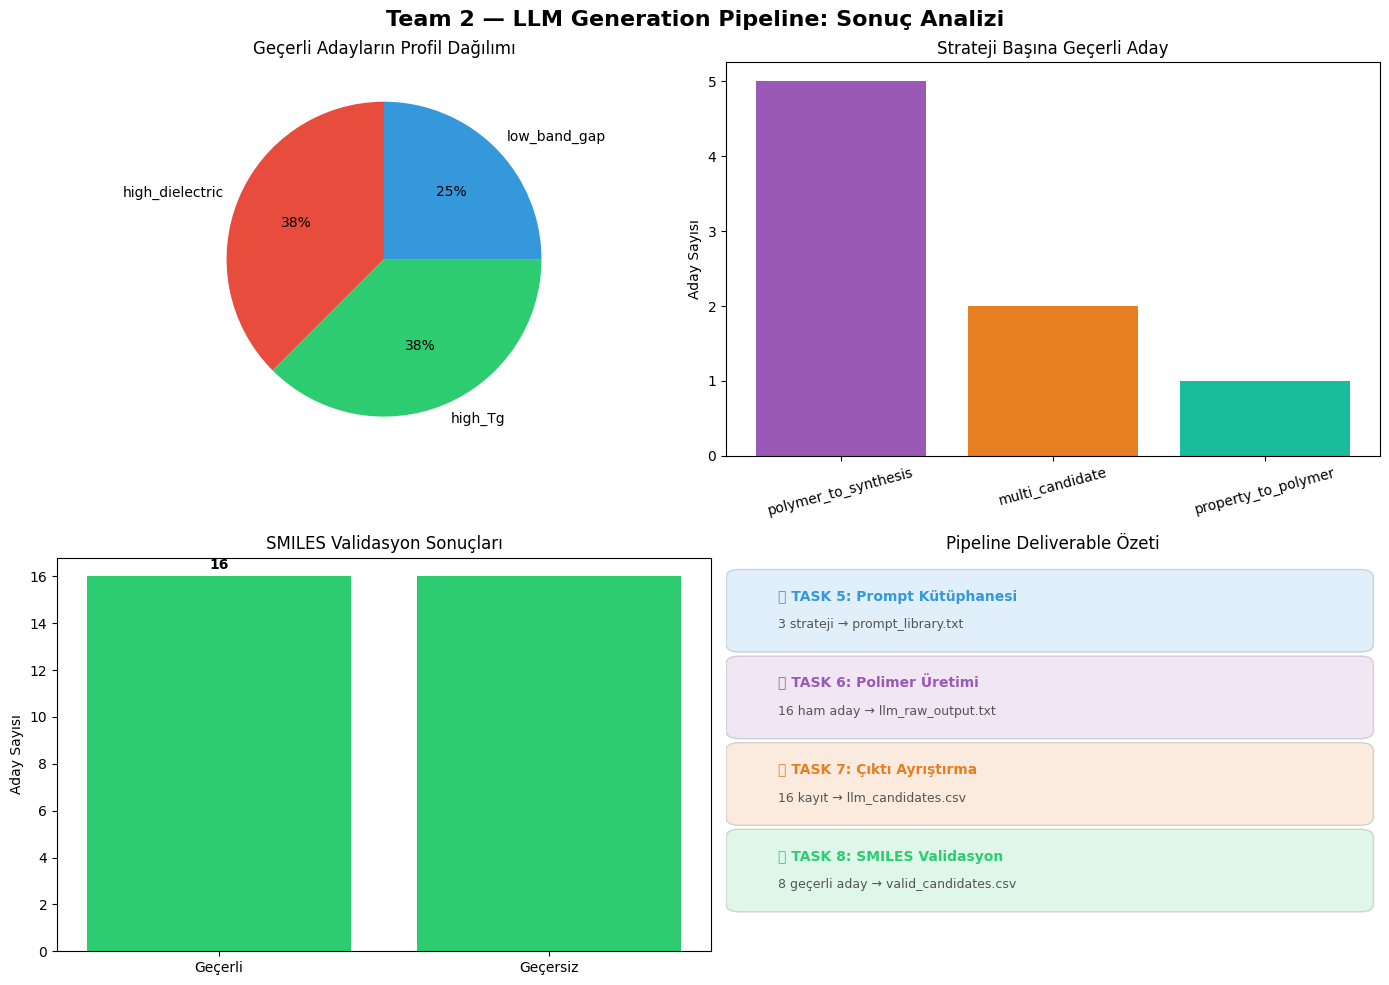

✅ Görsel → pipeline_results.png


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 10 — Sonuç Analizi
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if not df_llm_candidates.empty and 'df_valid' in dir() and not df_valid.empty:

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Team 2 — LLM Generation Pipeline: Sonuç Analizi', fontsize=16, fontweight='bold')

    colors = {'high_dielectric': '#e74c3c', 'low_band_gap': '#3498db', 'high_Tg': '#2ecc71'}

    # 1. Profil dağılımı (pasta)
    ax1 = axes[0, 0]
    profile_counts = df_valid["profile"].value_counts()
    if not profile_counts.empty:
        wedge_colors = [colors.get(p, '#95a5a6') for p in profile_counts.index]
        ax1.pie(profile_counts.values, labels=profile_counts.index,
                autopct='%1.0f%%', colors=wedge_colors, startangle=90)
        ax1.set_title('Geçerli Adayların Profil Dağılımı')

    # 2. Strateji dağılımı (bar)
    ax2 = axes[0, 1]
    strategy_counts = df_valid["strategy"].value_counts()
    if not strategy_counts.empty:
        ax2.bar(strategy_counts.index, strategy_counts.values,
                color=['#9b59b6', '#e67e22', '#1abc9c'][:len(strategy_counts)])
        ax2.set_title('Strateji Başına Geçerli Aday')
        ax2.set_ylabel('Aday Sayısı')
        ax2.tick_params(axis='x', rotation=15)

    # 3. Validasyon özeti
    ax3 = axes[1, 0]
    val_counts = df_validated["smiles_valid"].value_counts()
    bar_colors = ['#2ecc71' if v else '#e74c3c' for v in val_counts.index]
    bars = ax3.bar(['Geçerli', 'Geçersiz'], val_counts.values, color=bar_colors)
    ax3.set_title('SMILES Validasyon Sonuçları')
    ax3.set_ylabel('Aday Sayısı')
    for bar, val in zip(bars, val_counts.values):
        ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold')

    # 4. Pipeline özet metrikleri
    ax4 = axes[1, 1]
    ax4.axis('off')
    summary_text = [
        ("TASK 5", "Prompt Kütüphanesi", "3 strateji → prompt_library.txt", '#3498db'),
        ("TASK 6", "Polimer Üretimi", f"{len(all_candidates)} ham aday → llm_raw_output.txt", '#9b59b6'),
        ("TASK 7", "Çıktı Ayrıştırma", f"{len(df_llm_candidates)} kayıt → llm_candidates.csv", '#e67e22'),
        ("TASK 8", "SMILES Validasyon", f"{len(df_valid)} geçerli aday → valid_candidates.csv", '#2ecc71'),
    ]
    for i, (task, title, detail, color) in enumerate(summary_text):
        y = 0.85 - i * 0.22
        ax4.add_patch(mpatches.FancyBboxPatch((0.02, y-0.07), 0.95, 0.17,
                      boxstyle="round,pad=0.02", facecolor=color, alpha=0.15, transform=ax4.transAxes))
        ax4.text(0.08, y+0.04, f"✅ {task}: {title}", transform=ax4.transAxes,
                 fontweight='bold', fontsize=10, color=color)
        ax4.text(0.08, y-0.03, detail, transform=ax4.transAxes, fontsize=9, color='#555')
    ax4.set_title('Pipeline Deliverable Özeti')

    plt.tight_layout()
    plt.savefig('pipeline_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Görsel → pipeline_results.png")

else:
    print("Görselleştirme için yeterli veri yok.")

## 🔗 BÖLÜM 11 — Task 9 Hazırlığı: Team 1 ile Birleştirme Şeması

Team 2'nin doğrulanmış adaylarını, Team 1'in `clean_dataset.csv`'si ile
birleştirilebilecek ortak şemaya dönüştürür.

**Ortak şema:** `smiles`, `band_gap`, `dielectric`, `Tg`, `source`

> **GNN entegrasyonu sonrası:** GNN aktifken `gnn_predicted_*` sütunları da taşınır.
> Bu, downstream GNN katmanının "LLM ne hedefledi vs GNN ne ölçtü" karşılaştırmasını
> yapabilmesini sağlar — projenin tutarlılık doğrulamasının veri temeli budur.

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 11 — Task 9: Dataset ↔ LLM Alignment Hazırlığı
# Team 1'in clean_dataset.csv'si ile birleştirmek için ortak şema
# ─────────────────────────────────────────────────────────────────────────────

# Task 9 ortak şeması (proje dokümanından)
TASK9_SCHEMA = [
    "smiles",           # Kanonik SMILES (birincil anahtar)
    "band_gap",         # eV cinsinden
    "dielectric",       # birimsiz
    "Tg",               # K cinsinden
    "source"            # 'dataset' (Team 1) veya 'LLM' (Team 2)
]

if 'df_valid' in dir() and not df_valid.empty:
    # Team 2 çıktısını Task 9 şemasına dönüştür
    df_task9_team2 = pd.DataFrame()
    df_task9_team2["smiles"]      = df_valid["polymer_SMILES"]
    df_task9_team2["band_gap"]    = pd.to_numeric(df_valid["target_band_gap_eV"], errors='coerce')
    df_task9_team2["dielectric"]  = pd.to_numeric(df_valid["target_dielectric"], errors='coerce')
    df_task9_team2["Tg"]          = pd.to_numeric(df_valid["target_Tg_K"], errors='coerce')
    df_task9_team2["source"]      = "LLM"
    # Ek bilgiler
    df_task9_team2["profile"]     = df_valid["profile"]
    df_task9_team2["strategy"]    = df_valid["strategy"]
    df_task9_team2["monomers"]    = df_valid["monomers"]
    df_task9_team2["reaction_type"] = df_valid["reaction_type"]
    df_task9_team2["temperature_K"] = df_valid["temperature_K"]
    df_task9_team2["solvent"]     = df_valid["solvent"]
    # GNN bağımsız tahminleri (varsa) — tutarlılık karşılaştırması için
    for col in ["gnn_validated", "gnn_predicted_dielectric",
                "gnn_predicted_band_gap", "gnn_predicted_Tg"]:
        if col in df_valid.columns:
            df_task9_team2[col] = df_valid[col]

    df_task9_team2.to_csv('team2_task9_ready.csv', index=False)

    print("✅ Task 9 hazırlığı tamamlandı → team2_task9_ready.csv")
    print(f"   Team 1 ile birleştirilmek üzere {len(df_task9_team2)} aday hazır")
    print(f"\n📋 Task 9 Ortak Şema:")
    for col in TASK9_SCHEMA:
        print(f"   • {col}")

    print(f"\n💡 Team 1'e iletilecek mesaj:")
    print(f"   clean_dataset.csv → şu sütunlar gerekli: {TASK9_SCHEMA}")
    print(f"   'source' değeri: 'dataset' olarak ayarlayın")
    print(f"   Sonra: pd.concat([df_team1_schema, df_task9_team2]) ile birleştirin")

else:
    print("ℹ️  valid_candidates.csv mevcut değil, Task 9 hazırlığı atlandı.")

✅ Task 9 hazırlığı tamamlandı → team2_task9_ready.csv
   Team 1 ile birleştirilmek üzere 8 aday hazır

📋 Task 9 Ortak Şema:
   • smiles
   • band_gap
   • dielectric
   • Tg
   • source

💡 Team 1'e iletilecek mesaj:
   clean_dataset.csv → şu sütunlar gerekli: ['smiles', 'band_gap', 'dielectric', 'Tg', 'source']
   'source' değeri: 'dataset' olarak ayarlayın
   Sonra: pd.concat([df_team1_schema, df_task9_team2]) ile birleştirin


## 📥 BÖLÜM 12 — Tüm Dosyaları İndir

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 12 — Deliverable Dosyalarını Colab'dan İndir
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files
import os

deliverables = [
    ("prompt_library.txt",      "Task 5 — Prompt Kütüphanesi"),
    ("llm_raw_output.txt",      "Task 6 — Ham LLM Çıktıları"),
    ("llm_candidates.csv",      "Task 7 — Yapılandırılmış Adaylar"),
    ("valid_candidates.csv",    "Task 8 — Doğrulanmış Adaylar"),
    ("team2_task9_ready.csv",   "Task 9 — Birleştirme Şeması"),
    ("pipeline_results.png",    "Görselleştirme")
]

print("📦 Team 2 Deliverables:")
print()
for filename, description in deliverables:
    if os.path.exists(filename):
        size_kb = os.path.getsize(filename) / 1024
        print(f"  ✅ {filename:35s} ({size_kb:.1f} KB) — {description}")
    else:
        print(f"  ❌ {filename:35s} — BULUNAMADI")

print()
print("İndirmek istediğiniz dosyayı aşağıya yazın:")
print("Örnek: files.download('valid_candidates.csv')")

📦 Team 2 Deliverables:

  ✅ prompt_library.txt                  (7.1 KB) — Task 5 — Prompt Kütüphanesi
  ✅ llm_raw_output.txt                  (16.0 KB) — Task 6 — Ham LLM Çıktıları
  ✅ llm_candidates.csv                  (4.1 KB) — Task 7 — Yapılandırılmış Adaylar
  ✅ valid_candidates.csv                (2.6 KB) — Task 8 — Doğrulanmış Adaylar
  ✅ team2_task9_ready.csv               (1.2 KB) — Task 9 — Birleştirme Şeması
  ✅ pipeline_results.png                (166.4 KB) — Görselleştirme

İndirmek istediğiniz dosyayı aşağıya yazın:
Örnek: files.download('valid_candidates.csv')


In [24]:
# Tek tek indirme:
# files.download('prompt_library.txt')
# files.download('llm_raw_output.txt')
# files.download('llm_candidates.csv')
# files.download('valid_candidates.csv')
# files.download('team2_task9_ready.csv')

# Tümünü indir:
for filename, _ in deliverables:
    if os.path.exists(filename):
        files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📋 Pipeline Özet

| Görev | Durum | Çıktı |
|-------|-------|-------|
| **Task 5** — Prompt Engineering | ✅ | `prompt_library.txt` |
| **Task 6** — Polymer Generation | ✅ | `llm_raw_output.txt` |
| **Task 7** — Output Parsing | ✅ | `llm_candidates.csv` |
| **Task 8** — SMILES Validation (Gate 1) | ✅ | `valid_candidates.csv` |
| **Gate 2** — GNN köprüsü | 🔌 Arayüz hazır (placeholder) | `team2_task9_ready.csv` |

### Mimari Özet (Kapalı Döngü)
```
Gerçek Polimer DB (Team 1, gelene kadar 10 referans örnek)
    ↓  FAISS vektör indeksleme (HuggingFace Embeddings)
RAG Retriever (k=3 benzer polimer)
    ↓  Bağlamsal few-shot örnekler
Llama 3.1-8B-Instruct (4-bit, T4 GPU, EOT terminator)
    ↓  Zorunlu JSON şeması
┌─ Self-Correction Loop (maks. 3 deneme) ───────────────┐
│   Gate 1: RDKit (kimyasal geçerlilik)                  │
│   Gate 2: GNN (özellik tutarlılığı) ── uyuşmazsa ──────┤ feedback
│                                                        │
└── tutarlı aday ────────────────────────────────────────┘
    ↓  Duplicate temizleme + gnn_predicted_* sütunları
valid_candidates.csv → Task 9 → final_merged_dataset.csv
```

### İki Aktifleştirme Şartı

1. **Team 1 verisi (`clean_dataset.csv`):** Bölüm 2B hücresini çalıştır → RAG gerçek veriyle güncellenir.
2. **GNN modeli:** Bölüm 6.5'teki `gnn_predict_properties()` doldur + `load_gnn_model(path)` çağır → Gate 2 gerçek filtrelemeye geçer, feedback döngüsü tam aktifleşir.

### Çıktı Sütunları (GNN entegrasyonu sonrası)

| Sütun grubu | Anlam |
|-------------|-------|
| `target_*` | LLM'in hedeflediği değerler (kullanıcı girdisi) |
| `gnn_predicted_*` | GNN'in yapıdan bağımsız tahmin ettiği değerler |
| `gnn_validated` | Bu aday GNN'den geçti mi (True) yoksa placeholder mı (False) |

> Tutarlılık doğrulamasının özü: `target_*` ≈ `gnn_predicted_*` ise LLM halüsinasyon yapmamış demektir.

## 🛡️ BÖLÜM 13 — GNN Otonom Ekran (advanced_validate_candidate)

Üretilen `df_valid` adaylarını GNN gatekeeper'ından geçirir: LLM hedefi ile GNN
tahmini arasındaki göreli hata > %25 **veya** GPR belirsizliği σ > 0.65 olan
adaylar `flagged` olarak işaretlenir. Sonuç `gnn_screened_candidates.csv` olarak
kaydedilir (raporun "otomatik güvenli sentez kapısı" çıktısı).

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BÖLÜM 13 — GNN Otonom Ekran: advanced_validate_candidate'i tüm adaylara uygula
# ─────────────────────────────────────────────────────────────────────────────
if 'df_valid' in dir() and not df_valid.empty:
    screen_rows = []
    for _, row in df_valid.iterrows():
        cand = {
            "candidate_id":  row.get("candidate_id", ""),
            "polymer_SMILES": row.get("polymer_SMILES", ""),
            "target_properties": {
                "dielectric_constant": pd.to_numeric(row.get("target_dielectric", 0), errors="coerce") or 0,
                "band_gap_eV":         pd.to_numeric(row.get("target_band_gap_eV", 0), errors="coerce") or 0,
                "Tg_K":                pd.to_numeric(row.get("target_Tg_K", 0), errors="coerce") or 0,
            },
        }
        v = advanced_validate_candidate(cand)
        gp = v["gnn_predicted"] or {}
        screen_rows.append({
            "candidate_id":   cand["candidate_id"],
            "polymer_SMILES": cand["polymer_SMILES"],
            "gnn_die":        gp.get("dielectric", ""),
            "gnn_band_gap":   gp.get("band_gap", ""),
            "gnn_Tg":         gp.get("Tg", ""),
            "gpr_sigma":      v["gpr_uncertainty"],
            "gnn_verdict":    "accepted" if v["accepted"] else "flagged",
            "reasons":        "; ".join(v["reasons"]),
        })
    df_screen = pd.DataFrame(screen_rows)
    df_screen.to_csv("gnn_screened_candidates.csv", index=False)

    n_acc = int((df_screen["gnn_verdict"] == "accepted").sum())
    n_flag = len(df_screen) - n_acc
    print("✅ Bölüm 13 tamamlandı → gnn_screened_candidates.csv")
    print(f"   Toplam aday: {len(df_screen)} | ✅ kabul: {n_acc} | 🚩 flagged: {n_flag}")
    print(f"   Eşikler: göreli hata>25%, σ>0.65")
    try:
        display(df_screen.head(10))
    except Exception:
        print(df_screen.head(10).to_string(index=False))
else:
    print("ℹ️  df_valid yok → GNN otonom ekran atlandı (önce üretim+validasyon hücrelerini çalıştırın).")